# Análisis EDA

Importación de librerías

In [1]:
import sys
sys.path.append("..") # sube de 'notebook/' a 'FINAL_INDIA/'

import pandas as pd
import numpy as np
from pathlib import Path

# visualizaciones
import matplotlib.pyplot as plt
import seaborn as sns

# recarga del módulo soporte
import importlib
import src.soporte as soporte
importlib.reload(soporte)

print("Librerías cargadas. Versión pandas:", pd.__version__)

from src.soporte import analisis_rapido1, analisis_rapido1eda, analisis_rapido2, analisis_rapido2eda, analisis_rapido3, analisis_rapido4, analisis_rapido4eda

Librerías cargadas. Versión pandas: 2.3.3


Carga de ficheros

In [2]:
nombres = ["df_merged", "df_Rank_final2", "df_Educ_clean", "df_Educ_state", "df_Rank_state"]

dfs = {
    nombre: pd.read_csv(f"../data/output/{nombre}.csv")
    for nombre in nombres
}

In [7]:
# son los 5 datasets con los que analizo el EDA, aunque el dataset principal es df_merged
df_Rank_final2 = dfs["df_Rank_final2"]
df_merged = dfs["df_merged"]
df_Educ_clean = dfs["df_Educ_clean"]
df_Rank_state = dfs["df_Rank_state"]
df_Educ_state = dfs["df_Educ_state"]


# Objetivo del análisis

Realizar un análisis exploratorio de datos (EDA) para:

Analizar la relación entre el nivel educativo de la población en India (según el censo de 2011) y el rendimiento de las instituciones educativas o universidades (según el ranking NIRF 2021–2025), identificando patrones, desigualdades regionales y posibles factores asociados a una mayor calidad educativa.

Podremos comprender la distribución del nivel educativo de la población por estado y por género.
Analizar la evolución y características del ranking NIRF (2021–2025).
Investigar si existe relación entre el nivel educativo de la población y el desempeño de las instituciones educativas.

En conclusión, el objetivo del EDA es evaluar si los estados con mayores niveles de alfabetización y educación presentan mejores resultados en los indicadores del ranking NIRF, analizando variables como TLR, RPC, OI, PERCEPTION y Score, y detectando tendencias, correlaciones y posibles explicaciones socioeducativas.

Ambos datasets contienen información a nivel estatal, lo que permite su integración mediante la variable “State”. No obstante, dado que el dataset del Ranking NIRF está a nivel de institución (o universidad), ha sido necesario realizar una agregación previa para obtener métricas representativas por estado.

Por ello, se ha realizado un proceso de agregación sobre los datos del Ranking NIRF para obtener indicadores representativos por estado (como medias o máximos de las variables educativas principales), permitiendo así una comparación coherente entre ambos conjuntos de datos.

También el dataset principal (Nivel educacional) se ha tenido que transformar para dejarlo a nivel estado, agregando todos los totales por grupos de edad.

Esta diferencia de granularidad puede influir en la interpretación de los resultados, ya que el rendimiento de unas pocas instituciones destacadas podría no reflejar el nivel educativo general del estado.

Importante: el análisis del bloque final (df_merged) es solo exploratorio debido al desfase temporal de 10-15 años entre los datos educativos (censo del 2011) y los universitarios (Rank 2021-2025). No se podrán establecer relaciones causales.

# Estructura del EDA

Debido a la complejidad de los datasets, tendremos que sacar conclusiones aisladas o conjuntas, según lo que vayamos a analizar.

1º. Entender cómo se distribuye la calidad educativa (según NIRF) entre los estados.

Para ello, analizo el dataset df_Rank_state (promedio de los indicadores educativos por estado).

2º. Bajar a nivel institución o universidad. Sigo analizando el dataset del Ranking NIRF pero usando el df_Rank_final2.

3º. Entender el nivel educativo de la población india y sus desigualdades.

Para ello, analizo el dataset df_Educ_clean.

4º.  Analizar si existe relación entre el nivel educativo de la población y el rendimiento institucional o universitario.

Para esta parte (dataset principal del análisis), realizaré la integración de los datasets: df_Rank_state y df_Educ_state obteniendo el dataset df_merged.

# 1º. Análisis del Ranking NIRF por estados (df_Rank_state)

In [8]:
analisis_rapido1(df_Rank_state)

Las 5 primeras filas son:


,State,Score_mean,Score_std,Rank_mean,TLR_mean,RPC_mean,GO_mean,OI_mean,PERCEPTION_mean,n_institutos
0,Andhra Pradesh,50.502500,4.467945,60.416667,62.400833,30.123333,78.025833,60.386667,11.012500,12
1,Assam,54.645625,10.366683,55.562500,62.683125,42.369375,76.821250,57.801875,19.825625,16
2,Bihar,50.558333,3.732037,64.000000,62.388333,38.158333,65.508333,57.880000,15.056667,6
3,Chandigarh,53.606667,3.124162,45.500000,55.536667,44.821667,72.016667,61.863333,29.160000,6
4,Delhi,62.854444,11.335680,28.777778,66.755278,51.135833,80.800000,68.135556,45.155833,36


Información básica del dataframe:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   State            23 non-null     object 
 1   Score_mean       23 non-null     float64
 2   Score_std        22 non-null     float64
 3   Rank_mean        23 non-null     float64
 4   TLR_mean         23 non-null     float64
 5   RPC_mean         23 non-null     float64
 6   GO_mean          23 non-null     float64
 7   OI_mean          23 non-null     float64
 8   PERCEPTION_mean  23 non-null     float64
 9   n_institutos     23 non-null     int64  
dtypes: float64(8), int64(1), object(1)
memory usage: 1.9+ KB


None

El número de duplicados es:0


State              0.0
Score_mean         0.0
Score_std          4.0
Rank_mean          0.0
TLR_mean           0.0
RPC_mean           0.0
GO_mean            0.0
OI_mean            0.0
PERCEPTION_mean    0.0
n_institutos       0.0
dtype: float64

In [9]:
df_Rank_state.columns

Index(['State', 'Score_mean', 'Score_std', 'Rank_mean', 'TLR_mean', 'RPC_mean',
       'GO_mean', 'OI_mean', 'PERCEPTION_mean', 'n_institutos'],
      dtype='object')

VARIABLES:

 State: Nombre del estado donde se encuentran los intitutos o universidades.

 TLR_mean (Enseñanza, Aprendizaje y Recursos): Puntuación media que representa la calidad del profesorado, la capacidad estudiantil, las instalaciones y el entorno académico.     

 RPC_mean (Investigación y Práctica Profesional): Puntuación media que refleja las publicaciones de investigación, las patentes y el impacto en la práctica profesional.      

 GO_mean (Resultados de Graduación): Puntuación media basada en la colocación de los estudiantes, los estudios superiores y el rendimiento académico.         

 OI_mean (Difusión e Inclusión): Puntuación media que mide la diversidad, la representación regional, el equilibrio de género y la inclusión.  

 PERCEPTION_mean: Puntuación media de reputación derivada de colegas académicos y empleadores.   

 Score_mean: Puntuación media general ponderada del NIRF, calculada utilizando todos los parámetros.  

 Score_std: Desviación típica de la puntuación media general ponderada del NIRF, calculada utilizando todos los parámetros.

 Rank_mean: Clasificación media nacional final asignada.    
 
 n_institutos: número total de institutos (o universidades) por cada estado.    


# EDA

Estadísticas básicas

In [19]:
analisis_rapido1eda(df_Rank_state)

ESTADÍSTICAS DESCRIPTIVAS


,count,mean,std,min,25%,50%,75%,max
Score_mean,23.0,53.40,4.00,42.79,51.15,53.61,55.75,62.85
Score_std,22.0,6.61,3.31,2.13,3.79,5.60,9.97,12.68
Rank_mean,23.0,54.01,13.77,28.78,45.20,54.27,59.07,90.00
TLR_mean,23.0,63.62,4.08,54.71,62.06,64.00,66.57,68.55
RPC_mean,23.0,38.39,8.52,16.31,33.21,40.13,42.60,55.33
GO_mean,23.0,72.92,4.43,64.28,69.94,72.63,76.78,80.80
OI_mean,23.0,61.17,4.80,51.63,57.84,61.86,64.66,68.14
PERCEPTION_mean,23.0,21.00,10.13,3.18,12.54,19.83,28.24,45.16
n_institutos,23.0,21.74,20.38,1.00,7.50,16.00,30.50,90.00



VALORES ÚNICOS - STATE

 State (23 únicos):
['Andhra Pradesh' 'Assam' 'Bihar' 'Chandigarh' 'Delhi' 'Gujarat'
 'Himachal Pradesh' 'Jammu and Kashmir' 'Jharkhand' 'Karnataka' 'Kerala'
 'Madhya Pradesh' 'Maharashtra' 'Meghalaya' 'Odisha' 'Pondicherry'
 'Punjab' 'Rajasthan' 'Tamil Nadu' 'Telangana' 'Uttar Pradesh'
 'Uttarakhand' 'West Bengal']


Estas estadísticas básicas nos dicen lo siguiente:

Score_mean (53.4): puntuaciones bastante agrupadas, poca dispersión (std=4)

Rank_mean (54): rankings muy dispersos (std=13.7), hay mucha diferencia entre estados

TLR_mean (63.6): la métrica más alta, relativamente homogénea

RPC_mean (38.4): la más baja junto con PERCEPTION, con bastante variabilidad

GO_mean (72.9): la puntuación más alta de todas, consistente entre estados

PERCEPTION_mean (21): muy baja y muy dispersa (std=10), gran desigualdad entre estados

n_institutos: va de 1 a 90, mediana 16 — la mayoría de estados tienen pocos institutos pero algunos concentran muchísimos.



A continuación, vamos a profundizar más en el EDA haciéndonos estas preguntas:

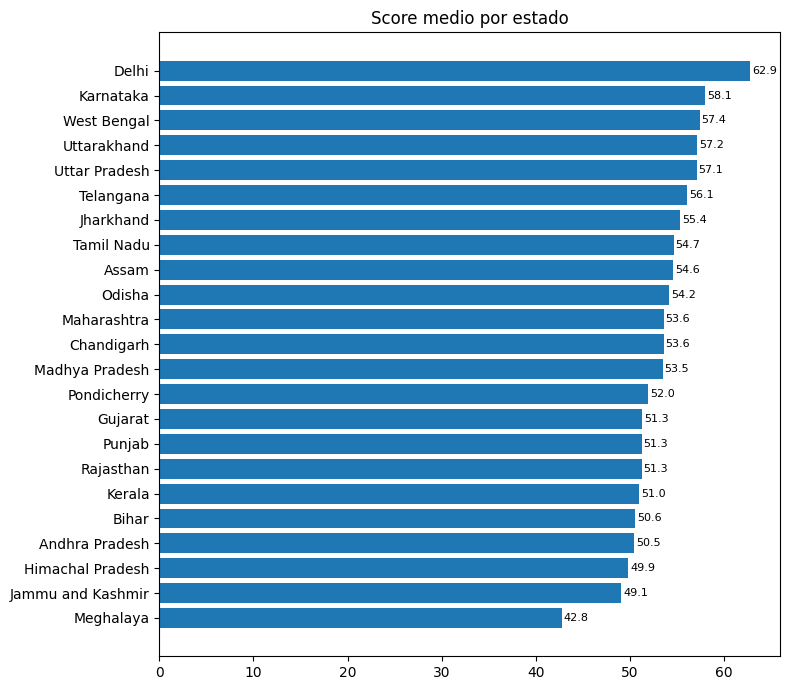

In [20]:
# ¿Qué estados obtienen el mejor Score medio?

df_sorted = df_Rank_state.sort_values('Score_mean', ascending=True)

fig, ax = plt.subplots(figsize=(8, 7))
bars = ax.barh(df_sorted['State'], df_sorted['Score_mean'])
for bar, val in zip(bars, df_sorted['Score_mean']):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2, f'{val:.1f}', va='center', fontsize=8)
ax.set_title('Score medio por estado')
plt.tight_layout()
plt.show()

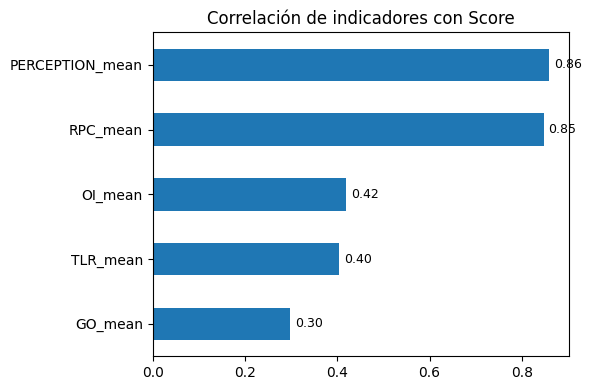

In [21]:
# Correlaciones indicadores: ¿Qué indicador está más correlacionado con el Score medio?, 
# es decir, ¿qué indicador explica mejor la puntuación general de las universidades?

# Hay que tener en cuenta que estoy midiendo la relación entre instituciones promedio, no año a año, puesto que estoy trabajando con el df a nivel estado

cols = ['TLR_mean', 'RPC_mean', 'GO_mean', 'OI_mean', 'PERCEPTION_mean']
correlaciones = df_Rank_state[cols].corrwith(df_Rank_state['Score_mean']).sort_values()

fig, ax = plt.subplots(figsize=(6, 4))
bars = correlaciones.plot.barh(ax=ax)
for bar, val in zip(ax.patches, correlaciones):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', fontsize=9)
ax.set_title('Correlación de indicadores con Score')
plt.tight_layout()
plt.show()

,TLR_mean,RPC_mean,GO_mean,OI_mean,PERCEPTION_mean,Score_mean
TLR_mean,1.00,-0.03,0.25,0.22,0.15,0.40
RPC_mean,-0.03,1.00,-0.03,0.36,0.72,0.85
GO_mean,0.25,-0.03,1.00,-0.39,0.27,0.30
OI_mean,0.22,0.36,-0.39,1.00,0.34,0.42
PERCEPTION_mean,0.15,0.72,0.27,0.34,1.00,0.86
Score_mean,0.40,0.85,0.30,0.42,0.86,1.00


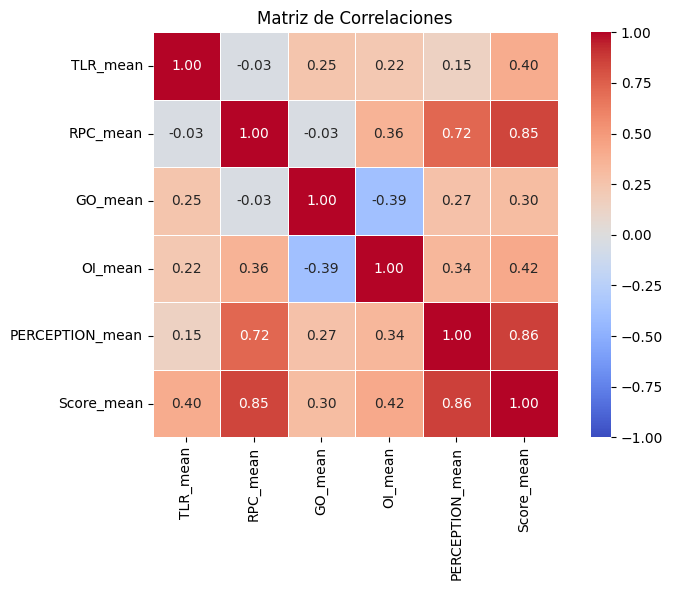

In [22]:
## ¿Cómo se relacionan los indicadores entre sí? 
cols = ['TLR_mean', 'RPC_mean', 'GO_mean', 'OI_mean', 'PERCEPTION_mean', 'Score_mean']

corr = df_Rank_state[cols].corr()

display(corr.round(2))

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title("Matriz de Correlaciones")
plt.tight_layout()
plt.show()

La correlación entre algunas variables es muy alta, lo que significa que están muy relacionadas. Si sube una, sube la otra y viceversa, si baja una, baja la otra.

RPC vs Score presenta una correlación de 0.85. Una universidad que investiga y publica mucho casi garantiza una puntuación muy alta.

PERCEPTION vs Score presenta también una alta correlación (0.86). Pero PERCEPTION vs RPC también están altamente correladas (0.72). Esto significa que la reputación pesa casi tanto como la investigación a la hora de valorar una universidad. El problema es que ambas van de la mano (RPC–PERCEPTION = 0.72), es decir, la reputación y la investigación no son independientes: las universidades más conocidas o "famosas" son conocidas porque investigan, y las que investigan acaban siendo las mejor valoradas. 

TLR vs Score también se relacionan pero de manera más moderada (0.40). Por tanto, la calidad docente es muy importante pero no es tan relevante a la hora de valorarlas.

GO vs Score presenta una correlación del 30% (0.30). Esto es, los resultados de los graduados aportan algo en el Score, pero de forma mucho más pausada.

OI vs Score (0.42). Esto indica que la inclusión, la diversidad también impacta en el Score.


Conclusión final: el ranking NIRF premia fundamentalmente a la investigación y reputación, que además están vinculadas entre sí, mientras que los 
resultados de graduación (GO) o del OI impactan menos en la valoración general.

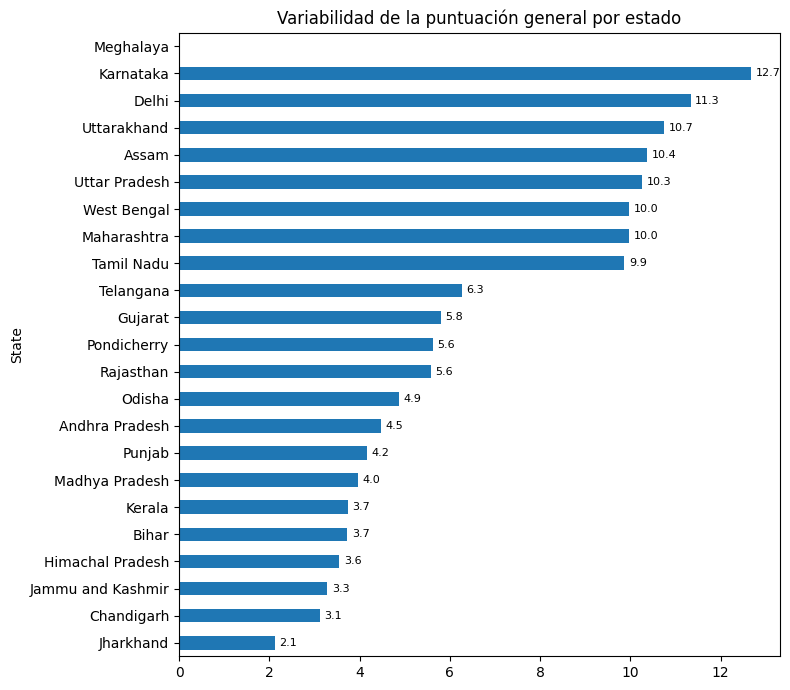

In [23]:
# ¿Qué estados tienen mayor variabilidad?

df_sorted = df_Rank_state.sort_values('Score_std', ascending=True)

fig, ax = plt.subplots(figsize=(8, 7))
df_sorted.plot.barh(x='State', y='Score_std', ax=ax, legend=False)
for bar, val in zip(ax.patches, df_sorted['Score_std']):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2, f'{val:.1f}', va='center', fontsize=8)
ax.set_title('Variabilidad de la puntuación general por estado')
plt.tight_layout()
plt.show()

Este gráfico muestra cuánto varía la puntuación general (Score) de las universidades dentro de cada estado, es decir, si existe mucha o poca 
variabilidad de universidades en cada estado, en cuanto al Score se refiere.

Una desviación típica alta (variabilidad alta) significa que ese estado tiene universidades muy dispares entre sí, es decir, algunas muy buenas pero otras mucho peores.Y una desviación típica baja, significa que todas las universidades de ese estado son muy parecidas, o lo que es lo mismo, con una puntuación general parecida, que no fluctúa tanto.

In [24]:
# ¿Por qué no aparece la barra del estado de Meghalaya?

In [25]:
print(df_Rank_state[df_Rank_state['State'] == 'Meghalaya']['Score_std'])

13   NaN
Name: Score_std, dtype: float64


El estado de Meghalaya tiene una sola universidad en el ranking. Con un único dato es imposible calcular la desviación típica. 

Otra pregunta que me surge a partir de aquí es: 

¿Un estado con desviación alta tiene buen Score medio porque tiene una universidad muy top o no?

No tiene por qué ser así, que tenga variabilidad alta no implica que tenga una puntuación alta en todas las universidades, habrá de todo.
Vamos a averiguarlo:

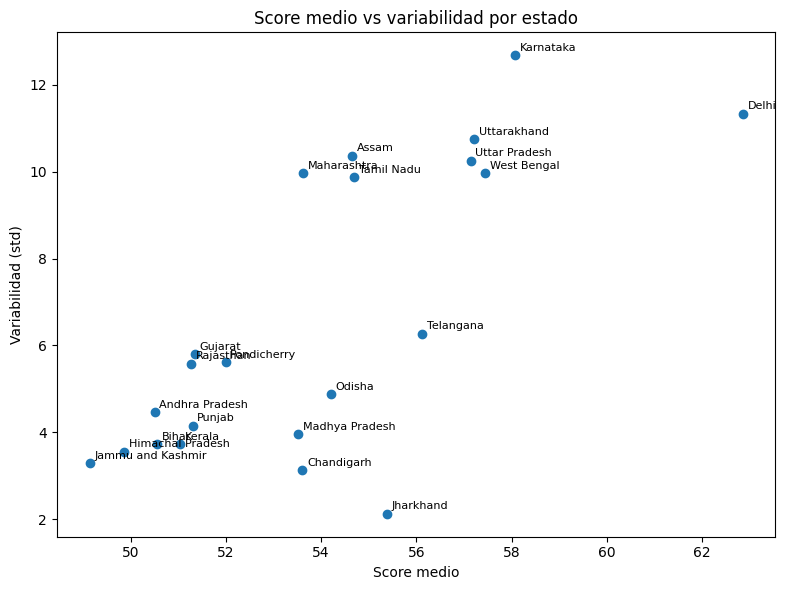

In [26]:
# Diagrama de dispersión

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df_Rank_state['Score_mean'], df_Rank_state['Score_std'])
for _, row in df_Rank_state.iterrows():
    ax.text(row['Score_mean'] + 0.1, row['Score_std'] + 0.1, row['State'], fontsize=8)
ax.set_xlabel('Score medio')
ax.set_ylabel('Variabilidad (std)')
ax.set_title('Score medio vs variabilidad por estado')
plt.tight_layout()
plt.show()

Este gráfico de puntos se interpreta imaginándonos cuatro cuadrantes:

1. Superior derecho: Score alto + alta std → Tendrá una universidad top que será la que le de ese score alto. El estado de Delhi obviamente tendrá ese tipo de universidades muy importantes. Pero no quiere decir que todas las universidades sean top.

2. Inferior derecho: Score alto + std → estados con universidades consistentemente buenas.

3. Superior izquierdo: Score bajo + alta std → Desigualdad entre las universidades, con alguna universidad decente entre muchas malas.

4. Inferior izquierdo: Score bajo + baja std → Uniformemente universidades mucho más mediocres. 

¿Hay relación entre el número de universidades y el Score medio? Es decir, ¿se cumple que a mayor numero de universidades, mayor Score medio?

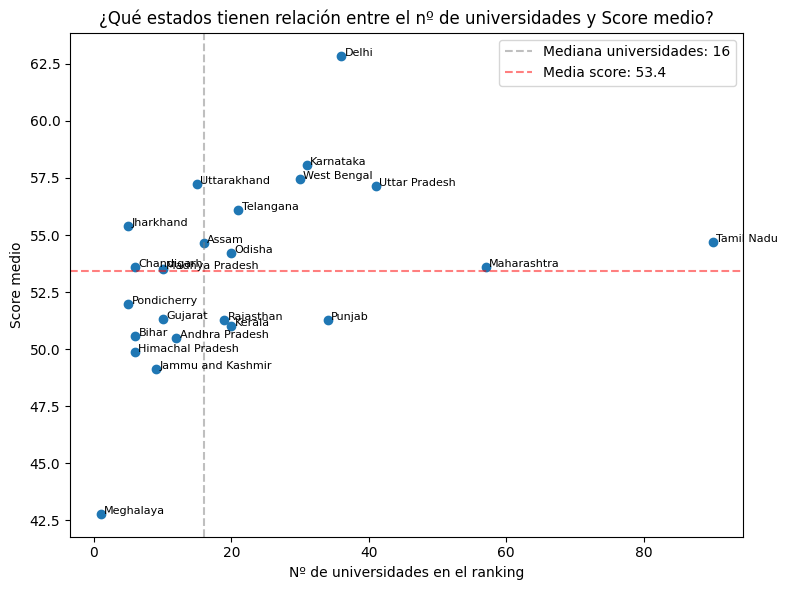

In [27]:
# Diagrama de dispersión: muestro la media y mediana

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df_Rank_state['n_institutos'], df_Rank_state['Score_mean'])
for _, row in df_Rank_state.iterrows():
    ax.text(row['n_institutos'] + 0.5, row['Score_mean'], row['State'], fontsize=8)
ax.axvline(df_Rank_state['n_institutos'].median(), linestyle='--', color='gray', alpha=0.5, label=f'Mediana universidades: {df_Rank_state["n_institutos"].median():.0f}')
ax.axhline(df_Rank_state['Score_mean'].mean(), linestyle='--', color='red', alpha=0.5, label=f'Media score: {df_Rank_state["Score_mean"].mean():.1f}')
ax.set_xlabel('Nº de universidades en el ranking')
ax.set_ylabel('Score medio')
ax.set_title('¿Qué estados tienen relación entre el nº de universidades y Score medio?')
ax.legend()
plt.tight_layout()
plt.show()

La conclusión es clara, tener más universidades en cada uno de los estados no implica mayor calidad.

Cuando un estado tiene muchas universidades en el ranking, inevitablemente entran instituciones de nivel medio-bajo que arrastran la media hacia abajo. Los estados con pocas universidades pero bien seleccionadas tienen scores más altos.

Jharkhand — solo 5 universidades y score de 55.4. El caso más eficiente del dataset.
Uttarakhand — 15 universidades y score de 57.2. Justo en la mediana de universidades pero muy por encima en calidad.
Assam — similar a Uttarakhand, 16 universidades y score de 54.6.

El cuadrante inferior izquierdo también es interesante porque muestra los estados que tienen pocas universidades y mala calidad — Meghalaya, Jammu & Kashmir, Himachal Pradesh. Es decir, tener pocas universidades no garantiza calidad, pero los que sí la tienen con pocos son casos dignos de destacar.

La correlación entre ambas variables es probablemente débil.

¿Qué indicador tiene más dispersión entre estados?

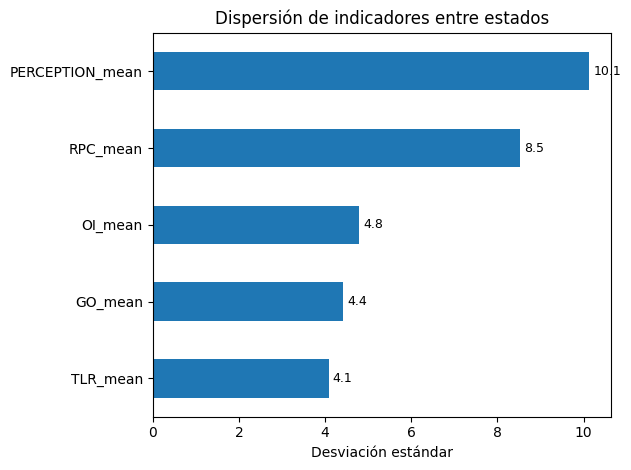

In [28]:
# Diagrama de barras:

cols = ['TLR_mean', 'RPC_mean', 'GO_mean', 'OI_mean', 'PERCEPTION_mean']

std = df_Rank_state[cols].std().sort_values(ascending=True)
ax = std.plot.barh()
for bar, val in zip(ax.patches, std):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2, f'{val:.1f}', va='center', fontsize=9)
plt.title('Dispersión de indicadores entre estados')
plt.xlabel('Desviación estándar')
plt.tight_layout()
plt.show()

PERCEPTION es con diferencia el indicador más desigual entre estados (std ~10), seguido de RPC (std ~8.5). Esto encaja perfectamente con lo que obtuve antes en la correlación — son los dos indicadores que más correlacionan con el Score, y además son los que más varían entre estados. Es decir, son los que más diferencian a unos estados de otros.

En cambio TLR, GO y OI son bastante homogéneos — todos los estados tienen niveles parecidos en esos tres indicadores, por lo que no sirven para distinguir quién es mejor.

Por tanto, podemos decir que la reputación y la capacidad de investigación son los indicadores que más separan a los buenos estados de los malos.No la calidad docente ni los resultados de los graduados.

# 2º. Análisis del df_Rank_final2

A continuación, tras este análisis más general, bajamos al detalle de cada universidad individual. 

Este dataset consta de 500 filas con universidades individuales, sus scores, rankings y el año. Voy a preguntarme las siguientes cuestiones:

¿Cuáles son las mejores universidades?

¿Cómo evoluciona la calidad a lo largo de los años?

¿Qué estados concentran las mejores universidades?

¿Cómo se distribuyen los scores? ¿Hay muchas mediocres y pocas excelentes?

In [29]:
analisis_rapido2(df_Rank_final2)

Las 5 primeras filas son:


,Institute ID,Institute Name,TLR,RPC,GO,OI,PERCEPTION,City,State,Score,Rank,Año
0,IR-O-U-0456,Indian Institute of Technology Madras,85.61,92.51,86.32,63.57,97.13,Chennai,Tamil Nadu,86.76,1,2021
1,IR-O-U-0220,Indian Institute of Science,79.13,91.48,78.23,58.39,100.00,Bengaluru,Karnataka,82.67,2,2021
2,IR-O-U-0306,Indian Institute of Technology Bombay,83.52,87.81,80.86,57.48,91.96,Mumbai,Maharashtra,82.52,3,2021
3,IR-O-I-1074,Indian Institute of Technology Delhi,84.02,84.46,75.07,67.97,93.89,New Delhi,Delhi,81.75,4,2021
4,IR-O-I-1075,Indian Institute of Technology Kanpur,80.50,75.23,80.74,56.97,79.30,Kanpur,Uttar Pradesh,76.50,5,2021


Información básica del dataframe:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Institute ID    500 non-null    object 
 1   Institute Name  500 non-null    object 
 2   TLR             500 non-null    float64
 3   RPC             500 non-null    float64
 4   GO              500 non-null    float64
 5   OI              500 non-null    float64
 6   PERCEPTION      500 non-null    float64
 7   City            500 non-null    object 
 8   State           500 non-null    object 
 9   Score           500 non-null    float64
 10  Rank            500 non-null    int64  
 11  Año             500 non-null    int64  
dtypes: float64(6), int64(2), object(4)
memory usage: 47.0+ KB


None

El número de duplicados es:0


Institute ID      0.0
Institute Name    0.0
TLR               0.0
RPC               0.0
GO                0.0
OI                0.0
PERCEPTION        0.0
City              0.0
State             0.0
Score             0.0
Rank              0.0
Año               0.0
dtype: float64

In [30]:
df_Rank_final2.columns

Index(['Institute ID', 'Institute Name', 'TLR', 'RPC', 'GO', 'OI',
       'PERCEPTION', 'City', 'State', 'Score', 'Rank', 'Año'],
      dtype='object')

VARIABLES:

Institute ID: identificador único del instituto (o universidad).

Institute Name: nombre del instituto. 

TLR (Enseñanza, Aprendizaje y Recursos): Puntuación que representa la calidad del profesorado, la capacidad estudiantil, las instalaciones y el entorno académico.     

RPC (Investigación y Práctica Profesional): Puntuación que refleja las publicaciones de investigación, las patentes y el impacto en la práctica profesional.      

GO (Resultados de Graduación): Puntuación basada en la colocación de los estudiantes, los estudios superiores y el rendimiento académico.         

OI (Difusión e Inclusión): Puntuación que mide la diversidad, la representación regional, el equilibrio de género y la inclusión.  

PERCEPTION: Puntuación de reputación derivada de colegas académicos y empleadores.   

City: ciudad en donde se encuestra la universidad o instituto.

State: Nombre del estado en donde se encuentra la universidad o instituto.

Score: Puntuación general ponderada del NIRF, calculada utilizando todos los parámetros.  

Rank: Clasificación nacional final asignada a cada instituto.   

Año: año al que corresponde la obtención de estos indicadores del ranking NIRF.

# EDA

Estadísticas básicas

In [31]:
analisis_rapido2eda(df_Rank_final2)

ESTADÍSTICAS DESCRIPTIVAS


,count,mean,std,min,25%,50%,75%,max
TLR,500.0,64.76,9.17,39.94,57.80,64.74,71.45,90.58
RPC,500.0,40.31,16.28,10.35,28.95,38.75,48.15,92.51
GO,500.0,73.73,9.51,49.57,66.69,72.28,79.56,100.00
OI,500.0,61.64,7.63,36.58,56.14,60.90,66.45,83.83
PERCEPTION,500.0,24.53,21.77,0.00,9.57,17.89,29.49,100.00
Score,500.0,54.89,9.27,41.10,48.66,52.72,58.56,87.59
Rank,500.0,50.47,28.89,1.00,25.75,50.50,75.25,100.00
Año,500.0,2023.00,1.42,2021.00,2022.00,2023.00,2024.00,2025.00



VALORES ÚNICOS VARIABLES CATEGÓRICAS

 Institute ID (130 únicos):
['IR-O-U-0456' 'IR-O-U-0220' 'IR-O-U-0306' 'IR-O-I-1074' 'IR-O-I-1075'
 'IR-O-U-0573' 'IR-O-U-0560' 'IR-O-U-0053' 'IR-O-U-0109' 'IR-O-U-0500'
 'IR-O-U-0570' 'IR-O-U-0436' 'IR-O-U-0108' 'IR-O-U-0575' 'IR-O-U-0234'
 'IR-O-U-0013' 'IR-O-U-0042' 'IR-O-U-0496' 'IR-O-U-0120' 'IR-O-U-0323'
 'IR-O-U-0490' 'IR-O-U-0447' 'IR-O-U-0467' 'IR-O-U-0305' 'IR-O-U-0439'
 'IR-O-U-0205' 'IR-O-U-0308' 'IR-O-U-0701' 'IR-O-U-0391' 'IR-O-U-0273'
 'IR-O-U-0378' 'IR-O-U-0237' 'IR-O-U-0139' 'IR-O-U-0235' 'IR-O-U-0572'
 'IR-O-U-0304' 'IR-O-U-0363' 'IR-O-U-0078' 'IR-O-U-0356' 'IR-O-U-0377'
 'IR-O-U-0357' 'IR-O-U-0476' 'IR-O-U-0260' 'IR-O-U-0497' 'IR-O-I-1480'
 'IR-O-U-0584' 'IR-O-I-1357' 'IR-O-U-0006' 'IR-O-I-1441' 'IR-O-U-0272'
 'IR-O-U-0064' 'IR-O-U-0262' 'IR-O-U-0473' 'IR-O-U-0098' 'IR-O-U-0334'
 'IR-O-U-0222' 'IR-O-U-0435' 'IR-O-U-0355' 'IR-O-U-0025' 'IR-O-U-0523'
 'IR-O-U-0474' 'IR-O-U-0136' 'IR-O-U-0027' 'IR-O-U-0107' 'IR-O-U-0253'
 'IR-O-U-0

Evolución general de los indicadores año tras año

In [32]:
## La media de cada uno de los indicadores aumenta cada año:
df_Rank_final2.groupby("Año")[['TLR','RPC','GO','OI','PERCEPTION','Score']].mean()

,TLR,RPC,GO,OI,PERCEPTION,Score
Año,,,,,,
2021,59.0618,36.4687,71.1867,58.6717,23.8844,51.1514
2022,62.8731,38.0749,74.0477,60.6544,24.8648,53.6463
2023,64.0593,40.9245,74.4969,62.3532,24.8239,55.1119
2024,68.6010,42.0677,74.0997,62.5188,24.8371,56.7559
2025,69.2209,44.0297,74.8106,64.0035,24.2362,57.7612


Todos los indicadores han mejorado, en media, con el paso del tiempo. Año a año, el Score y el resto de variables que conforman el NIRF
aumentan su valor.

Evolución del Score gráficamente

Año
2021    51.1514
2022    53.6463
2023    55.1119
2024    56.7559
2025    57.7612
Name: Score, dtype: float64


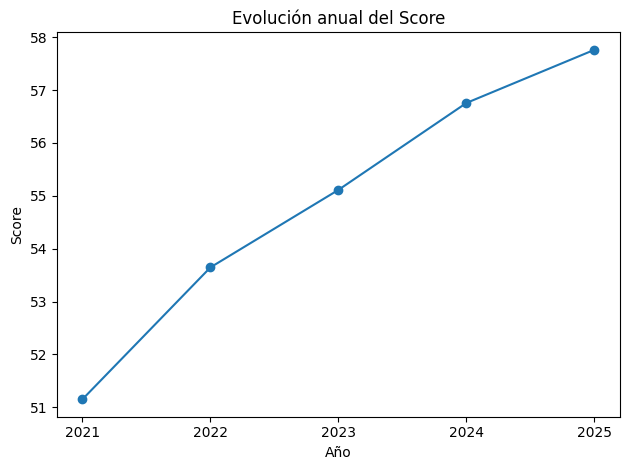

In [22]:
evolucion = df_Rank_final2.groupby('Año')['Score'].mean()
print(evolucion)

evolucion.plot(marker='o')
plt.title('Evolución anual del Score')
plt.xlabel('Año')
plt.ylabel('Score')
plt.xticks(df_Rank_final2['Año'].unique())
plt.tight_layout()
plt.show()

Muy claro. El sistema universitario indio está mejorando de forma consistente — el score ha subido de 51.2 en 2021 a 57.8 en 2025, casi 7 puntos en 5 años.

La tendencia es continua y sin ningún año de retroceso, lo cual es notable. Además la curva parece estar desacelerando ligeramente hacia 2024-2025, lo que podría indicar que el sistema está llegando a un techo. Aunque tendríamos que indagar mucho más y hacer predicciones, pero no vamos a hacerlas en este análisis exploratorio.

In [23]:
# Aquí muestro los primeros 10 resultados de la evolución del Score durante los últimos 5 años. Estas son las dos universidades
# más top en cuanto a la puntuación general:
print(df_Rank_final2[['Institute Name', 'State', 'Score', 'Rank', 'Año']].sort_values('Score', ascending=False).head(10))

                            Institute Name       State  Score  Rank   Año
100  Indian Institute of Technology Madras  Tamil Nadu  87.59     1  2022
400  Indian Institute of Technology Madras  Tamil Nadu  87.31     1  2025
0    Indian Institute of Technology Madras  Tamil Nadu  86.76     1  2021
200  Indian Institute of Technology Madras  Tamil Nadu  86.69     1  2023
300  Indian Institute of Technology Madras  Tamil Nadu  86.42     1  2024
401            Indian Institute of Science   Karnataka  85.00     2  2025
101            Indian Institute of Science   Karnataka  83.57     2  2022
301            Indian Institute of Science   Karnataka  83.28     2  2024
201            Indian Institute of Science   Karnataka  83.09     2  2023
1              Indian Institute of Science   Karnataka  82.67     2  2021


In [24]:
# Yendo un poco más al detalle: Score medio por universidad (promedio de todos los años)
top = df_Rank_final2.groupby(['Institute Name', 'State'])['Score'].mean().reset_index()
print(top.sort_values('Score', ascending=False).head(10))

                                   Institute Name          State    Score
54          Indian Institute of Technology Madras     Tamil Nadu  86.9540
37                    Indian Institute of Science      Karnataka  83.5220
45          Indian Institute of Technology Bombay    Maharashtra  81.8280
46           Indian Institute of Technology Delhi          Delhi  81.4220
52          Indian Institute of Technology Kanpur  Uttar Pradesh  77.2740
53       Indian Institute of Technology Kharagpur    West Bengal  74.4280
4   All India Institute of Medical Sciences Delhi          Delhi  71.6375
57         Indian Institute of Technology Roorkee    Uttarakhand  71.5580
48        Indian Institute of Technology Guwahati          Assam  68.9000
67                    Jawaharlal Nehru University          Delhi  67.8900


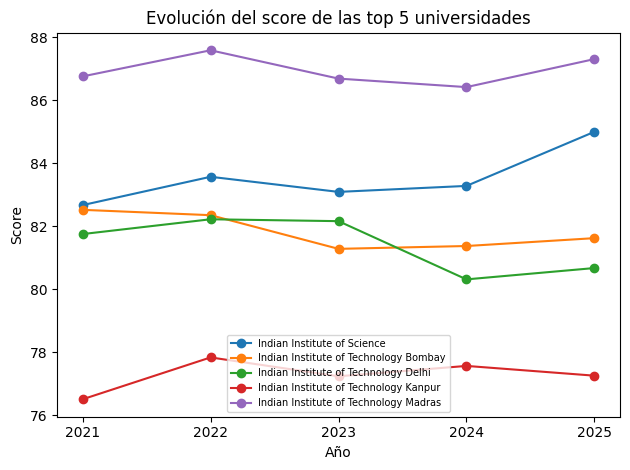

In [25]:
## ¿Cómo evolucionan los scores de las mejores universidades a lo largo de los años?

# Seleccionamos las 5 mejores universidades, ordenando de mayor a menor y lo convierte a lista
top5 = top.sort_values('Score', ascending=False).head(5)['Institute Name'].tolist()

# Filtramos el dataset original con esas 5 universidades
df_top5 = df_Rank_final2[df_Rank_final2['Institute Name'].isin(top5)]

# Grafica de la evolución
for name, group in df_top5.groupby('Institute Name'):
    plt.plot(group['Año'], group['Score'], marker='o', label=name)

plt.title('Evolución del score de las top 5 universidades')
plt.xlabel('Año')
plt.ylabel('Score')
plt.legend(fontsize=7)
plt.xticks(df_top5['Año'].unique())
plt.tight_layout()
plt.show()

IIT Madras (morado) es inalcanzable — lidera todos los años y se mantiene estable entre 86 y 88. Es la universidad dominante del sistema.

IISc (azul) es la historia más llamativa — es la única que tiene una tendencia claramente ascendente, subiendo de 82.7 en 2021 a 85 en 2025. Está recortando distancia con IIT Madras.

IIT Bombay e IIT Delhi (naranja y verde) son estables pero sin tendencia clara, oscilan en torno a 81-83 sin mejorar ni empeorar significativamente.

IIT Kanpur (rojo) es el más bajo de las top 5 y el más volátil — subió en 2022 y desde entonces ha bajado continuamente.

La conclusión general es que las posiciones están muy consolidadas — las mismas universidades lideran año tras año sin grandes cambios, lo que sugiere que el sistema universitario indio de élite es bastante estático. 

Histogramas

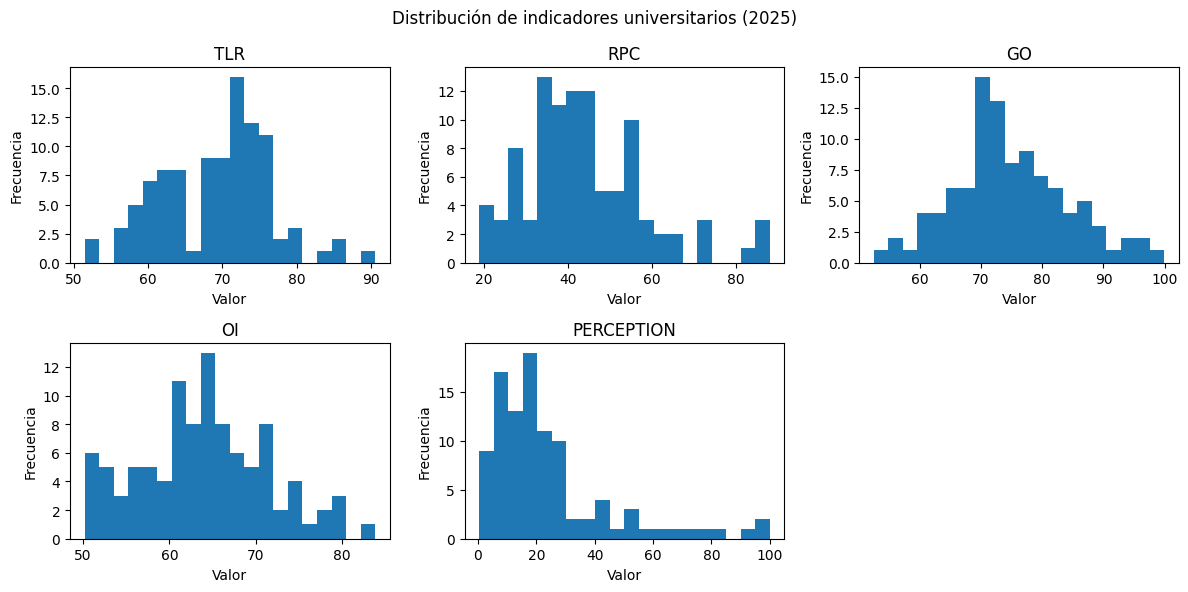

In [26]:
## Voy a seleccionar el año 2025 e interpreto resultados

df2_2025 = df_Rank_final2[df_Rank_final2['Año'] == 2025]
cols = ['TLR', 'RPC', 'GO', 'OI', 'PERCEPTION']

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.flatten()

for i, col in enumerate(cols):
    axes[i].hist(df2_2025[col], bins=20)
    axes[i].set_title(col)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')

axes[-1].set_visible(False)
plt.suptitle('Distribución de indicadores universitarios (2025)')
plt.tight_layout()
plt.show()

Ahora puedo interpretar mejor estos histogramas y ver las diferencias con respecto a los iniciales de la parte del Análisis preliminar (recordamos que había duplicidad de los años 2020 y 2021)

TLR y GO — distribuciones bastante centradas y simétricas alrededor de 70. La mayoría de universidades tienen valores parecidos en estos dos indicadores, lo que confirma lo que vimos antes: no diferencian mucho entre universidades.

RPC — distribución más dispersa y sesgada hacia la izquierda. La mayoría de universidades tienen RPC bajo (20-40), y pocas alcanzan valores altos. La investigación de calidad es minoritaria.

OI — distribución bastante uniforme entre 50 y 80, con una cola hacia valores bajos. Hay diversidad real entre universidades en este indicador.

PERCEPTION — la más llamativa. Está muy concentrada en valores bajos (0-20), con una cola larga hacia la derecha. La gran mayoría de universidades tienen reputación muy baja, y solo unas pocas tienen reputación alta. Es el indicador más desigual, lo cual encaja perfectamente con lo que vimos en el análisis de dispersión.

La conclusión general es que el sistema universitario indio tiene una élite muy pequeña con alta reputación e investigación, mientras la mayoría de universidades son mediocres en esos indicadores pero homogéneas en docencia y resultados de graduación.

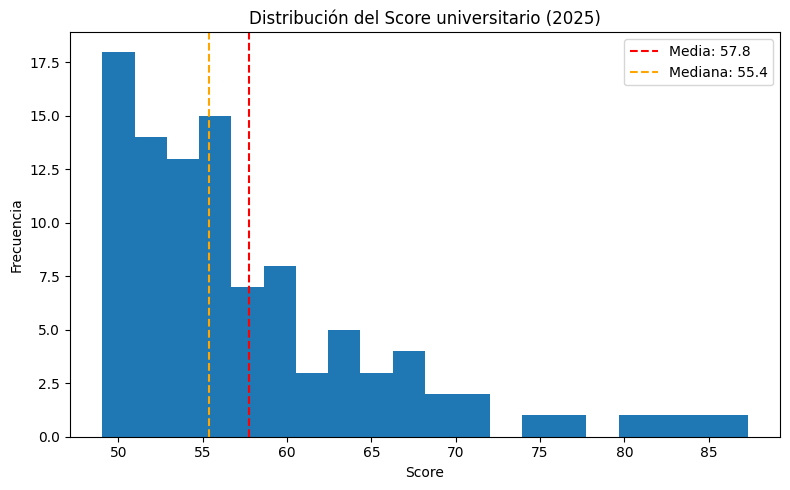

In [27]:
## ¿Cómo se distribuyen las puntuaciones (Score)? ¿Hay muchas universidades mediocres y pocas excelentes?

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df2_2025['Score'], bins=20)
ax.axvline(df2_2025['Score'].mean(), color='red', linestyle='--', label=f'Media: {df2_2025["Score"].mean():.1f}')
ax.axvline(df2_2025['Score'].median(), color='orange', linestyle='--', label=f'Mediana: {df2_2025["Score"].median():.1f}')
ax.set_title('Distribución del Score universitario (2025)')
ax.set_xlabel('Score')
ax.set_ylabel('Frecuencia')
ax.legend()
plt.tight_layout()
plt.show()

La respuesta es sí — hay muchas universidades mediocres (por debajo de la media) y muy pocas excelentes.

La distribución está sesgada a la derecha: la gran mayoría de universidades se concentran entre 50 y 56 de Score, y a partir de ahí la frecuencia cae rápidamente. Solo unas pocas llegan a scores por encima de 75, y las que superan 80 son casos excepcionales (los IITs e IISc que vimos antes).
El hecho de que la media (57.8) esté por encima de la mediana (55.4) confirma el sesgo — las pocas universidades excelentes tiran de la media hacia arriba.

# 3º . Ahora analizo el df_Educ_clean: 

Recordemos lo que tiene este dataset: niveles educativos por estado y grupo de edad del censo de 2011. Algunas de las preguntas que me surgen son:

    ¿Qué estados tienen más analfabetismo?

    ¿Qué estados tienen más graduados?

    ¿Hay brecha de género en el acceso a la educación superior?

    ¿Cómo varía el nivel educativo por grupo de edad?

In [33]:
analisis_rapido3(df_Educ_clean)

Las 5 primeras filas son:


,Area Name,Total - Persons,Total - Males,Total - Females,Illiterate - Persons,Illiterate - Males,Illiterate - Females,Literate - Persons,Literate - Males,Literate - Females,...,Technical diploma - Persons,Technical diploma - Males,Technical diploma - Females,Graduate_Persons,Graduate_Males,Graduate_Females,Unclassified_Persons,Unclassified_Males,Unclassified_Females,age_group
0,Jammu and Kashmir,1485803,765394,720409,1485803,765394,720409,0,0,0,...,0,0,0,0,0,0,0,0,0,infancia
1,Jammu and Kashmir,217317,111487,105830,106713,50665,56048,110604,60822,49782,...,0,0,0,0,0,0,13,3,10,ninez
2,Jammu and Kashmir,321662,165379,156283,129296,58503,70793,192366,106876,85490,...,0,0,0,0,0,0,16,8,8,ninez
3,Jammu and Kashmir,231584,119404,112180,72575,31514,41061,159009,87890,71119,...,0,0,0,0,0,0,10,5,5,ninez
4,Jammu and Kashmir,368272,190872,177400,115170,48744,66426,253102,142128,110974,...,0,0,0,0,0,0,17,11,6,ninez


Información básica del dataframe:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 980 entries, 0 to 979
Data columns (total 41 columns):
 #   Column                                                       Non-Null Count  Dtype 
---  ------                                                       --------------  ----- 
 0   Area Name                                                    980 non-null    object
 1   Total - Persons                                              980 non-null    int64 
 2   Total - Males                                                980 non-null    int64 
 3   Total - Females                                              980 non-null    int64 
 4   Illiterate - Persons                                         980 non-null    int64 
 5   Illiterate - Males                                           980 non-null    int64 
 6   Illiterate - Females                                         980 non-null    int64 
 7   Literate - Persons                                     

None

El número de duplicados es:0


Area Name                                                      0.0
Total - Persons                                                0.0
Total - Males                                                  0.0
Total - Females                                                0.0
Illiterate - Persons                                           0.0
Illiterate - Males                                             0.0
Illiterate - Females                                           0.0
Literate - Persons                                             0.0
Literate - Males                                               0.0
Literate - Females                                             0.0
Literate w/o education level - Persons                         0.0
Literate w/o education level - Males                           0.0
Literate w/o education level - Females                         0.0
Bellow primary - Persons                                       0.0
Bellow primary - Males                                        

In [34]:
df_Educ_clean.columns

Index(['Area Name', 'Total - Persons', 'Total - Males', 'Total - Females',
       'Illiterate - Persons', 'Illiterate - Males', 'Illiterate - Females',
       'Literate - Persons', 'Literate - Males', 'Literate - Females',
       'Literate w/o education level - Persons',
       'Literate w/o education level - Males',
       'Literate w/o education level - Females', 'Bellow primary - Persons',
       'Bellow primary - Males', 'Bellow primary - Females',
       'Primary - Persons', 'Primary - Males', 'Primary - Females',
       'Middle - Persons', 'Middle - Males', 'Middle - Females',
       'Matric/Secondary - Persons', 'Matric/Secondary - Males',
       'Matric/Secondary - Females',
       'Higher second/Interm/Pre-University/Senior second - Persons',
       'Higher second/Interm/Pre-University/Senior second - Males',
       'Higher second/Interm/Pre-University/Senior second - Females',
       'Non-technical diploma - Persons', 'Non-technical diploma - Males',
       'Non-technical dip

VARIABLES:

Area Name: indica el nombre del estado.

Total - Persons: indica el total de personas en el estado por grupo de edad.

Total - Males: indica el total de hombres en el estado por grupo de edad.

Total - Females: indica el total de mujeres en el estado por grupo de edad.

Illiterate - Persons: indica el numero de personas totales analfabetas, por estado y grupo de edad.

Illiterate - Males: indica el numero de hombres analfabetos por estado y grupo de edad.

Illiterate - Females: indica el numero de mujeres analfabetas por estado y grupo de edad.

Literate - Persons: indica el total de personas alfabetizadas, por estado y grupo de edad.

Literate - Males: indica el total de hombres alfabetizados, por estado y grupo de edad.

Literate - Females: indica el numero total de mujeres alfabetizadas, por estado y grupo de edad.

Educational level - Literate without educational level - Persons: indica el total de personas alfabetizadas sin nivel educativo por estado y grupo de edad.

Educational level - Literate without educational level - Males: indica el total de hombres alfabetizados sin nivel educativo por estado y grupo de edad.

Educational level - Literate without educational level - Females: indica el total de mujeres alfabetizadas sin nivel educativo por estado y grupo de edad.

Educational level - Below primary - Persons: indica el total de personas que no han completado la educación primaria por estado y grupo de edad.

Educational level - Below primary - Males: indica el total de hombres que no han completado la educación primaria por estado y grupo de edad.

Educational level - Below primary - Females: indica el total de mujeres que no han completado la educación primaria por estado y grupo de edad.

Educational level - Primary - Persons: indica el total de personas con educación primaria o básica por estado y grupo de edad. 

Educational level - Primary - Males: indica el total de hombres con educación primaria o básica por estado y grupo de edad.

Educational level - Primary - Females: indica el total de mujeres con educación primaria o básica por estado y grupo de edad.

Educational level - Middle - Persons: indica el total de personas con educacion secundaria básica por estado y grupo de edad.

Educational level - Middle - Males: indica el  total de hombres con educación secundaria básica por estado y grupo de edad.

Educational level - Middle - Females: indica el total de mujeres con educación secundaria básica por estado y grupo de edad.

Educational level - Matric/Secondary - Persons: indica el total de personas con educación secundaria completa por estado y grupo de edad.

Educational level - Matric/Secondary - Males: indica el total de hombres con educación secundaria completa por estado y grupo de edad.

Educational level - Matric/Secondary - Females: indica el total de mujeres con educación secundaria commpleta por estado y grupo de edad.

Educational level - Higher secondary/Intermediate/Pre-University/Senior secondary - Persons: indica el total de personas con estudios preuniversitarios, o de bachillerato por estado y grupo de edad.

Educational level - Higher secondary/Intermediate/Pre-University/Senior secondary - Males: indica el total de hombres con estudios preuniversitarios, o de bachillerato por estado y grupo de edad.

Educational level - Higher secondary/Intermediate/Pre-University/Senior secondary - Females: indica el total de mujeres con estudios preuniversitarios, o de bachillerato por estado y grupo de edad.

Educational level - Non-technical diploma or certificate not equal to degree - Persons: indica el total de personas con estudios posteriores a secundaria pero no universitarios por estado y grupo de edad.

Educational level - Non-technical diploma or certificate not equal to degree - Males: indica el total de hombres con estudios posteriores a secundaria pero no universitarios por estado y grupo de edad.

Educational level - Non-technical diploma or certificate not equal to degree - Females: indica el total de mujeres con estudios posteriores a secundaria pero no universitarios por estado y grupo de edad.

Educational level - Technical diploma or certificate not equal to degree - Persons: indica el total de personas con diploma técnico o certificado que no equivale a un título universitario por estado y grupo de edad. 

Educational level - Technical diploma or certificate not equal to degree - Males: indica el total de hombres con diploma técnico o certificado que no equivale a un título universitario por estado y grupo de edad. 

Educational level - Technical diploma or certificate not equal to degree - Females: indica el total de mujeres con diploma técnico o certificado que no equivale a un título universitario por estado y grupo de edad. 

Educational level - Graduate & above - Persons: indica el total de personas con título universitario completo por estado y grupo de edad.

Educational level - Graduate & above - Males: indica el total de hombres con título universitario completo por estado y grupo de edad.

Educational level - Graduate & above - Females: indica el total de mujeres con título universitario completo por estado y grupo de edad.

Educational level - Unclassified - Persons: indica el total de personas totales no clasificadas por estado y grupo de edad.

Educational level - Unclassified - Males: indica el total de hombres no clasificados por estado y grupo de edad.

Educational level - Unclassified - Females: indica el total de mujeres no clasificadas por estado y grupo de edad.

# EDA

Estadísticas básicas

In [35]:
# Para simplificar el resumen estadístico, solo selecciono estas tres variables ya que, comprobamos que el total de alfabetizados 
# englobaba todas las demás (La variable "Literate - persons" es un agregado (suma de todos los niveles educativos desde Literate w/o educational level hasta Unclassified))
cols = ['Total - Persons', 'Illiterate - Persons', 'Literate - Persons']
df_Educ_clean[cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Total - Persons,980.0,1049602.38,2062775.43,53.0,29658.75,294580.0,1234991.5,31624628.0
Illiterate - Persons,980.0,477471.97,1592457.39,10.0,7298.00,70452.0,337230.0,31624628.0
Literate - Persons,980.0,572130.41,981197.38,0.0,16954.50,134172.5,710358.0,8169398.0


Conclusiones:

Total - Persons (población total):

La media es de 1,05 millones de personas, lo que coincide con el censo del 2011 (ya lo validamos en la parte del Análisis preliminar)
pero la desviación típica es enorme (2,06M), lo que indica una gran desigualdad entre estados — algunos muy pequeños y otros muy grandes.
El mínimo es 53 personas y el máximo 31,6 millones, lo que confirma esa dispersión extrema.

El 50% de los distritos tiene menos de 294.580 habitantes, es decir, la mayoría son distritos pequeños pero unos pocos gigantes elevan la media.

Illiterate - Persons (personas analfabetas):

Media de 477.000, pero con una std de 1,59M — también muy dispersa.
El mínimo es 10 personas y el máximo coincide con el de Total (31,6M), lo que sugiere que en los estados más grandes el analfabetismo en términos absolutos es muy alto.

El 50% de distritos tiene menos de 70.452 analfabetos.

Literate - Persons (personas alfabetizadas):

Media de 572.000, ligeramente superior a la de analfabetos, lo que indica que globalmente hay más alfabetizados que analfabetos en la mayoría de estados.

El mínimo es 0, lo que puede indicar estados sin población alfabetizada registrada. Ya vimos que esto puede darse.

Conclusión general: 
Los datos tienen una distribución muy sesgada a la derecha — la mayoría de distritos son pequeños pero hay outliers enormes. Para análisis más robustos, puede ser útil trabajar con tasas (por ejemplo, % de analfabetos sobre el total) en lugar de valores absolutos. Vamos a por ello.

Vamos a ahondar un poco más sobre estos datos:

In [36]:
# Tasa de analfabetismo por estado

analfabetismo = df_Educ_clean.groupby('Area Name').apply(
    lambda x: x['Illiterate - Persons'].sum() / x['Total - Persons'].sum() * 100
).sort_values(ascending=True)

print(analfabetismo.round(1))

Area Name
Kerala                       20.0
Mizoram                      25.6
Lakshadweep                  26.3
Goa                          26.9
Pondicherry                  28.5
Chandigarh                   28.6
Andaman & Nicobar Islands    28.9
Delhi                        30.2
Daman & Diu                  32.0
Himachal Pradesh             33.5
Maharashtra                  34.0
Tamil Nadu                   35.1
Tripura                      36.8
Punjab                       39.4
Manipur                      39.5
Uttarakhand                  39.9
West Bengal                  41.1
Gujarat                      41.1
Sikkim                       41.1
Karnataka                    42.4
Haryana                      42.8
Nagaland                     43.1
Odisha                       46.1
Chhattisgarh                 46.4
Assam                        47.4
Andhra Pradesh               47.6
Madhya Pradesh               47.6
Meghalaya                    50.1
Rajasthan                    51.0
Jamm

C:\Users\botic\AppData\Local\Temp\ipykernel_13112\3923084905.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  analfabetismo = df_Educ_clean.groupby('Area Name').apply(


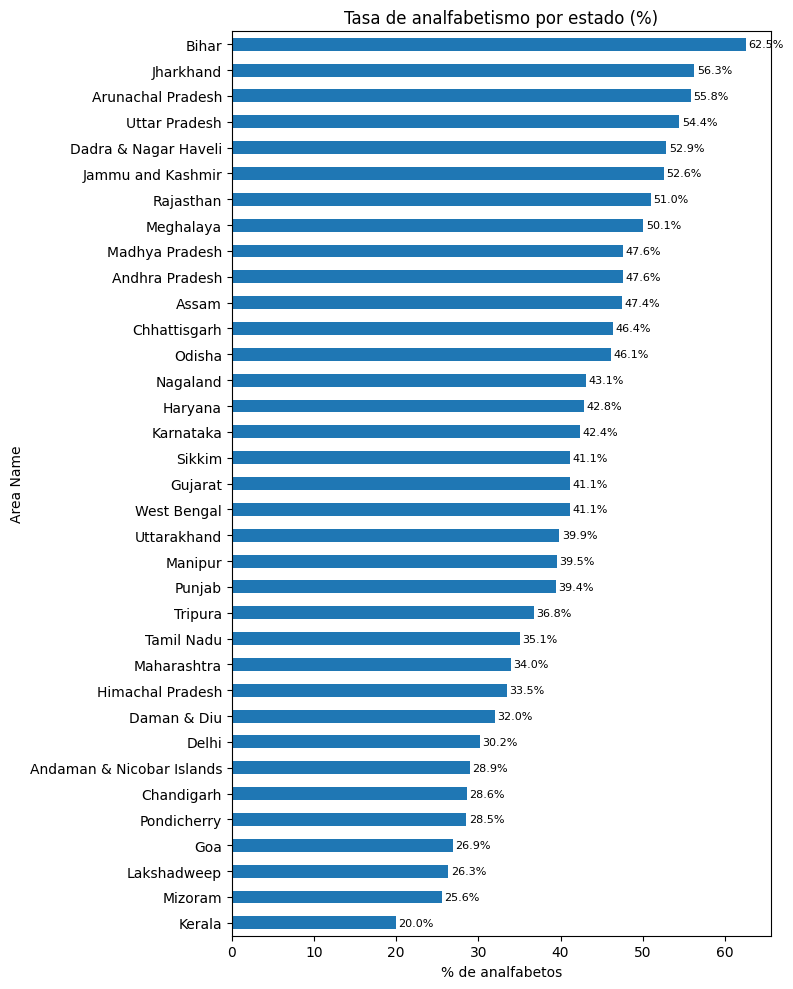

In [37]:
# Gráficamente, lo mismo de arriba:
# ¿Qué estados tienen mayor tasa de analfabetización?

fig, ax = plt.subplots(figsize=(8, 10))
analfabetismo.plot.barh(ax=ax)

# Etiquetas 
for bar in ax.patches:
    ax.text(
        bar.get_width() + 0.3,          
        bar.get_y() + bar.get_height() / 2,  
        f'{bar.get_width():.1f}%',       # texto con 1 decimal
        va='center', ha='left', fontsize=8
    )

ax.set_title('Tasa de analfabetismo por estado (%)')
ax.set_xlabel('% de analfabetos')
plt.tight_layout()
plt.show()

Bihar es el estado con más analfabetismo con diferencia (62.5%), seguido de Jharkhand (56.3%) y Arunachal Pradesh (55.8%). Curiosamente Jharkhand aparecía como un estado eficiente en el ranking universitario — tiene pocas universidades pero buenas. Esto sugiere que la élite universitaria coexiste con una base educativa muy débil.

En el extremo opuesto, Kerala es el estado más alfabetizado (solo 20% de analfabetismo), lo que encaja con su reputación histórica de ser el estado con mejor sistema educativo de India.

También llama la atención que Uttar Pradesh (49.7%) tiene analfabetismo muy alto pero aparecía entre los mejores estados en el ranking universitario — otro caso de élite universitaria desconectada de la educación general de la población.

In [38]:
# Tasa de alfabetismo por estado

alfabetismo = df_Educ_clean.groupby('Area Name').apply(
    lambda x: x['Literate - Persons'].sum() / x['Total - Persons'].sum() * 100
).sort_values(ascending=True)

print(alfabetismo.round(1))

Area Name
Bihar                        37.5
Jharkhand                    43.7
Arunachal Pradesh            44.2
Uttar Pradesh                45.6
Dadra & Nagar Haveli         47.1
Jammu and Kashmir            47.4
Rajasthan                    49.0
Meghalaya                    49.9
Madhya Pradesh               52.4
Andhra Pradesh               52.4
Assam                        52.6
Chhattisgarh                 53.6
Odisha                       53.9
Nagaland                     56.9
Haryana                      57.2
Karnataka                    57.6
Sikkim                       58.9
Gujarat                      58.9
West Bengal                  58.9
Uttarakhand                  60.1
Manipur                      60.5
Punjab                       60.6
Tripura                      63.2
Tamil Nadu                   64.9
Maharashtra                  66.0
Himachal Pradesh             66.5
Daman & Diu                  68.0
Delhi                        69.8
Andaman & Nicobar Islands    71.1
Chan

C:\Users\botic\AppData\Local\Temp\ipykernel_13112\4192546351.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  alfabetismo = df_Educ_clean.groupby('Area Name').apply(


C:\Users\botic\AppData\Local\Temp\ipykernel_13112\114816220.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  graduados = df_Educ_clean.groupby('Area Name').apply(


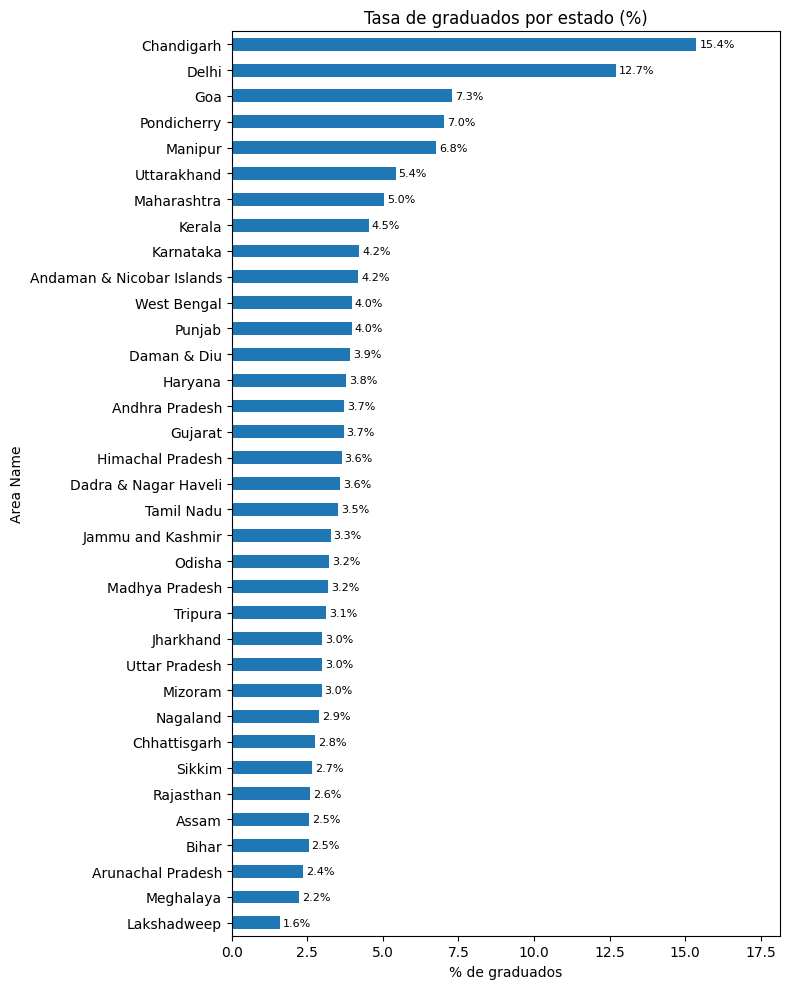

In [39]:
## Qué estados tienen más graduados?
graduados = df_Educ_clean.groupby('Area Name').apply(
    lambda x: x['Graduate_Persons'].sum() / x['Total - Persons'].sum() * 100
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 10))
graduados.plot.barh(ax=ax)

# Etiquetas 
for bar in ax.patches:
    ax.text(
        bar.get_width() + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f'{bar.get_width():.1f}%',
        va='center', ha='left', fontsize=8
    )

ax.set_title('Tasa de graduados por estado (%)')
ax.set_xlabel('% de graduados')
ax.set_xlim(right=ax.get_xlim()[1] + 2)  # espacio para las etiquetas
plt.tight_layout()
plt.show()

Varios hallazgos:

Chandigarh y Delhi lideran con diferencia en tasa de graduados. No es sorprendente — son territorios urbanos muy pequeños y con alta concentración de instituciones educativas y población cualificada.

Kerala aparece en mitad de la tabla, lo cual sorprende dado que era el estado con menos analfabetismo. Esto indica que Kerala tiene una población muy alfabetizada pero no necesariamente muy graduada — su fortaleza está en la educación básica y media, no en la superior.

Bihar y Jharkhand, que eran los peores en analfabetismo, aquí están en el extremo inferior también.

Los estados de Kerala, Mizoram y Lakshadweep que alcanzan los mayores porcentajes de alfabetizados, en este gráfico muestran bajos porcentajes 
de graduados.

La conclusión más interesante es que alfabetización y tasa de graduados no van siempre de la mano — son dos dimensiones distintas del sistema educativo. Esto hace que el cruce con el ranking universitario en el df_merged sea aún más rico.

C:\Users\botic\AppData\Local\Temp\ipykernel_13112\657467769.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  brecha = df_Educ_clean.groupby('Area Name').apply(


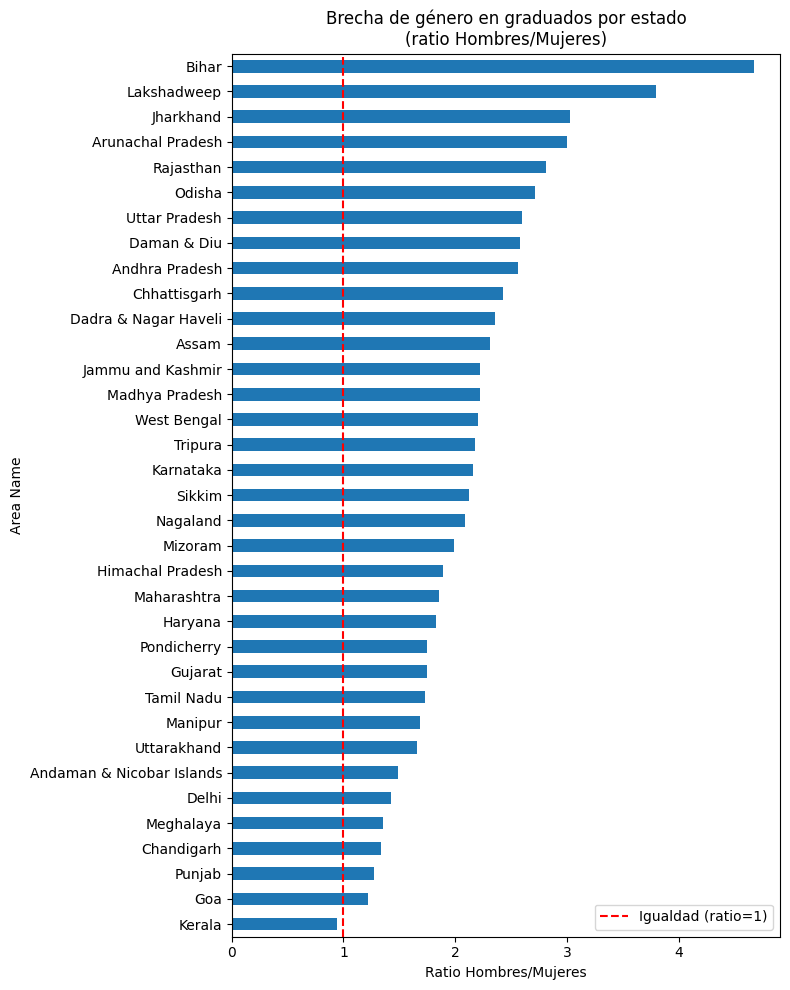

In [40]:
# Brecha de género en el nivel educativo "Graduado":

brecha = df_Educ_clean.groupby('Area Name').apply(
    lambda x: x['Graduate_Males'].sum() / x['Graduate_Females'].sum()
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 10))
brecha.plot.barh(ax=ax)
ax.axvline(1, color='red', linestyle='--', label='Igualdad (ratio=1)')
ax.set_title('Brecha de género en graduados por estado\n(ratio Hombres/Mujeres)')
ax.set_xlabel('Ratio Hombres/Mujeres')
ax.legend()
plt.tight_layout()
plt.show()

Contundente. Todos los estados están por encima de 1, lo que significa que en ningún estado de India hay más mujeres graduadas que hombres en 2011.
Los casos más extremos:

Bihar es de nuevo el peor — la brecha de género es enorme, hay muchos más hombres graduados que mujeres, lo que encaja con ser también el estado con más analfabetismo.
Lakshadweep y Jharkhand le siguen de cerca.

Los estados con menor brecha (más igualitarios) están en la parte inferior. Kerala, Delhi y Chandigarh son los más cercanos a la igualdad, lo cual es consistente con lo que hemos visto en los análisis anteriores.

La conclusión es clara: la brecha de género en educación superior sigue el mismo patrón que el analfabetismo — los estados con más analfabetismo son también los que tienen mayor desigualdad entre hombres y mujeres en el acceso a la universidad.

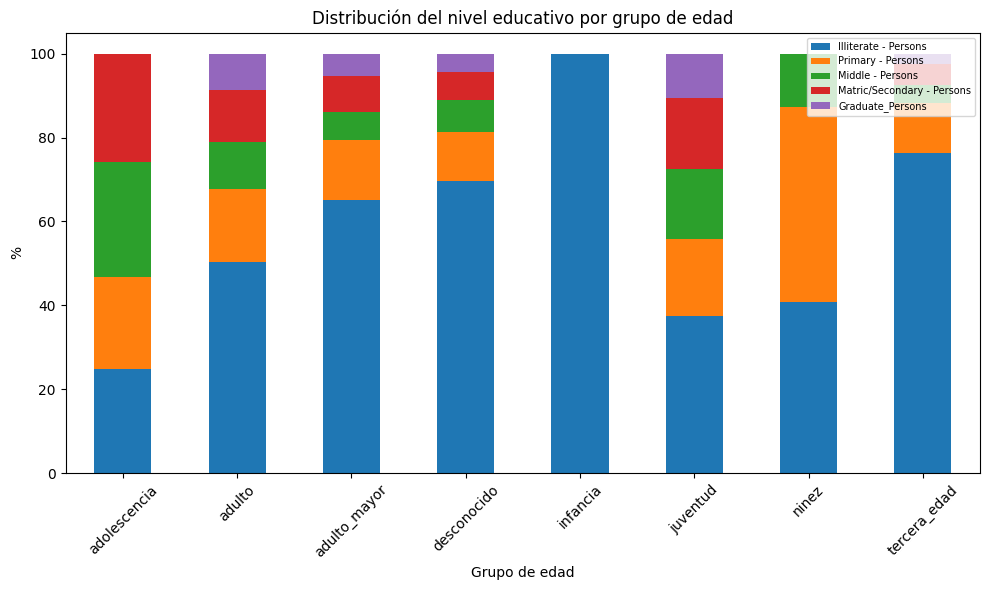

In [41]:
# Distribución del nivel educativo por grupos de edad:
niveles = ['Illiterate - Persons', 'Primary - Persons', 'Middle - Persons',
           'Matric/Secondary - Persons', 'Graduate_Persons']

edad = df_Educ_clean.groupby('age_group')[niveles].sum()
edad_pct = edad.div(edad.sum(axis=1), axis=0) * 100

edad_pct.plot(kind='bar', figsize=(10, 6), stacked=True)
plt.title('Distribución del nivel educativo por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('%')
plt.legend(loc='upper right', fontsize=7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Varias observaciones:

Infancia es casi 100% analfabeta — tiene todo el sentido, son niños que aún no han tenido acceso a la educación.

Niñez y tercera edad tienen analfabetismo muy alto (40-75%) — la niñez porque están en proceso educativo, la tercera edad porque son generaciones que crecieron con menos acceso a la educación.

Adolescencia es el grupo más interesante — tiene el analfabetismo más bajo (25%) y la mayor proporción de niveles medios y secundaria. Es la generación más educada, lo que indica que el sistema educativo indio ha mejorado mucho con el tiempo.

Adulto y adulto mayor tienen analfabetismo alto (50-65%) comparado con adolescencia, lo cual confirma que las generaciones más jóvenes están mucho mejor formadas que las anteriores.

Juventud destaca por tener la mayor proporción de graduados (morado) — es el grupo que ya ha completado la universidad.

Conclusión: hay una mejora generacional clara en el nivel educativo — cuanto más joven es el grupo de edad, menor es el analfabetismo y mayor el nivel educativo alcanzado. Esto es una buena señal para el futuro del sistema educativo indio.

# 4º. Análisis del df_merged.

Este dataset es el más interesante porque cruza dos conjuntos, la educación de la población y la calidad universitaria. 

Me pregunto algunas cuestiones:

¿Los estados con más graduados tienen mejores universidades?

¿Los estados con más analfabetismo tienen peores universidades?

¿La brecha de género en educación se refleja en la calidad universitaria?

¿Los estados sin universidades en el ranking tienen peor nivel educativo?

In [42]:
analisis_rapido4(df_merged)

Las 5 primeras filas son:


,Area Name,Total - Persons,Total - Males,Total - Females,Illiterate - Persons,Illiterate - Males,Illiterate - Females,Literate - Persons,Literate - Males,Literate - Females,...,Score_mean,Score_std,Rank_mean,TLR_mean,RPC_mean,GO_mean,OI_mean,PERCEPTION_mean,n_institutos,tiene_ranking
0,Andaman & Nicobar Islands,356152,192972,163180,103017,46141,56876,253135,146831,106304,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
1,Andhra Pradesh,76210007,38527413,37682594,36275684,15082625,21193059,39934323,23444788,16489535,...,50.502500,4.467945,60.416667,62.400833,30.123333,78.025833,60.386667,11.012500,12.0,True
2,Arunachal Pradesh,1097968,579941,518027,613183,276660,336523,484785,303281,181504,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
3,Assam,26655528,13777037,12878491,12640174,5588340,7051834,14015354,8188697,5826657,...,54.645625,10.366683,55.562500,62.683125,42.369375,76.821250,57.801875,19.825625,16.0,True
4,Bihar,82998509,43243795,39754714,51888932,22599419,29289513,31109577,20644376,10465201,...,50.558333,3.732037,64.000000,62.388333,38.158333,65.508333,57.880000,15.056667,6.0,True


Información básica del dataframe:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 87 columns):
 #   Column                                                          Non-Null Count  Dtype  
---  ------                                                          --------------  -----  
 0   Area Name                                                       35 non-null     object 
 1   Total - Persons                                                 35 non-null     int64  
 2   Total - Males                                                   35 non-null     int64  
 3   Total - Females                                                 35 non-null     int64  
 4   Illiterate - Persons                                            35 non-null     int64  
 5   Illiterate - Males                                              35 non-null     int64  
 6   Illiterate - Females                                            35 non-null     int64  
 7   Literate - Persons   

None

El número de duplicados es:0


Area Name                0.0
Total - Persons          0.0
Total - Males            0.0
Total - Females          0.0
Illiterate - Persons     0.0
                        ... 
GO_mean                 37.0
OI_mean                 37.0
PERCEPTION_mean         37.0
n_institutos            37.0
tiene_ranking            0.0
Length: 87, dtype: float64

# EDA

Estadísticas básicas

In [43]:
analisis_rapido4eda(df_merged)

INDICADORES DE RANKING


,count,mean,std,min,25%,50%,75%,max
Score_mean,22.0,53.28,4.05,42.79,51.09,53.56,55.21,62.85
Rank_mean,22.0,54.66,13.73,28.78,45.46,54.91,59.74,90.00
TLR_mean,22.0,63.50,4.13,54.71,61.90,63.87,66.61,68.55
RPC_mean,22.0,38.27,8.70,16.31,32.16,39.15,42.71,55.33
GO_mean,22.0,72.79,4.48,64.28,69.89,72.32,76.80,80.80
OI_mean,22.0,61.27,4.88,51.63,57.82,62.05,65.10,68.14
PERCEPTION_mean,22.0,20.66,10.24,3.18,12.40,19.55,27.57,45.16
n_institutos,22.0,21.77,20.86,1.00,6.75,15.50,30.75,90.00



VISIÓN GENERAL EDUCATIVA


,count,mean,std,min,25%,50%,75%,max
illiterate_persons_rate,35.0,0.4079,0.1038,0.1996,0.3274,0.4113,0.4762,0.6252
literate_persons_rate,35.0,0.5921,0.1038,0.3748,0.5238,0.5887,0.6726,0.8004



DESGLOSE POR NIVELES EDUCATIVOS


,count,mean,std,min,25%,50%,75%,max
illiterate_persons_rate,35.0,0.4079,0.1038,0.1996,0.3274,0.4113,0.4762,0.6252
literate_w_o_education_level_persons_rate,35.0,0.0159,0.0122,0.0028,0.0088,0.0118,0.0194,0.0670
bellow_primary_persons_rate,35.0,0.1452,0.0406,0.0848,0.1155,0.1363,0.1627,0.2692
primary_persons_rate,35.0,0.1507,0.0311,0.1004,0.1222,0.1526,0.1700,0.2142
middle_persons_rate,35.0,0.1025,0.0313,0.0529,0.0774,0.1001,0.1168,0.1895
matric_secondary_persons_rate,35.0,0.0865,0.0287,0.0469,0.0625,0.0873,0.1033,0.1423
graduate_persons_rate,35.0,0.0429,0.0278,0.0158,0.0293,0.0358,0.0420,0.1537


Los dos primeros bloques de estas estadísticas ya comenté las conclusiones. Resumiendo ya vimos que:

El Score medio es de 53.3 puntos, con poca dispersión (std=4), lo que indica que los estados son bastante homogéneos en calidad general.

El nº de institutos varía muchísimo (std=20.8): hay estados con 1 sola universidad y otros con 90, lo que refleja una gran desigualdad en representación.

PERCEPTION_mean es el indicador más variable (std=10.2) y con la media más baja (20.7), podríamos decir que es el criterio donde más difieren los estados.

De media, el 40.8% de la población es analfabeta, lo cual es un dato muy elevado.

La tasa de alfabetización (aquí se engloban muchos niveles educativos) asciende al 59%. Aqui entran aquellas personas que aun sin saber leer se consideran alfabetizadas.

Por último, los niveles Below primary (14.5%) y Primary (15.1%) son los niveles más comunes entre la población alfabetizada, lo que indica que la mayoría de quienes saben leer tienen estudios muy básicos.

Conclusión general: India muestra una pirámide educativa muy base-pesada, donde la mayoría de la población tiene estudios primarios o ninguno, y solo una minoría alcanza estudios universitarios.

In [44]:
# Paso 1 - Filtramos solo los estados con datos de ambas fuentes
df_analysis = df_merged.dropna(subset=['Score_mean']).copy()
print(f"Estados con datos completos: {len(df_analysis)}")

Estados con datos completos: 22


In [45]:
print(df_merged.columns.tolist())

['Area Name', 'Total - Persons', 'Total - Males', 'Total - Females', 'Illiterate - Persons', 'Illiterate - Males', 'Illiterate - Females', 'Literate - Persons', 'Literate - Males', 'Literate - Females', 'Literate w/o education level - Persons', 'Literate w/o education level - Males', 'Literate w/o education level - Females', 'Bellow primary - Persons', 'Bellow primary - Males', 'Bellow primary - Females', 'Primary - Persons', 'Primary - Males', 'Primary - Females', 'Middle - Persons', 'Middle - Males', 'Middle - Females', 'Matric/Secondary - Persons', 'Matric/Secondary - Males', 'Matric/Secondary - Females', 'Higher second/Interm/Pre-University/Senior second - Persons', 'Higher second/Interm/Pre-University/Senior second - Males', 'Higher second/Interm/Pre-University/Senior second - Females', 'Non-technical diploma - Persons', 'Non-technical diploma - Males', 'Non-technical diploma - Females', 'Technical diploma - Persons', 'Technical diploma - Males', 'Technical diploma - Females', 'Gr

In [46]:
df_merged.head()

,Area Name,Total - Persons,Total - Males,Total - Females,Illiterate - Persons,Illiterate - Males,Illiterate - Females,Literate - Persons,Literate - Males,Literate - Females,...,Score_mean,Score_std,Rank_mean,TLR_mean,RPC_mean,GO_mean,OI_mean,PERCEPTION_mean,n_institutos,tiene_ranking
0,Andaman & Nicobar Islands,356152,192972,163180,103017,46141,56876,253135,146831,106304,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
1,Andhra Pradesh,76210007,38527413,37682594,36275684,15082625,21193059,39934323,23444788,16489535,...,50.502500,4.467945,60.416667,62.400833,30.123333,78.025833,60.386667,11.012500,12.0,True
2,Arunachal Pradesh,1097968,579941,518027,613183,276660,336523,484785,303281,181504,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
3,Assam,26655528,13777037,12878491,12640174,5588340,7051834,14015354,8188697,5826657,...,54.645625,10.366683,55.562500,62.683125,42.369375,76.821250,57.801875,19.825625,16.0,True
4,Bihar,82998509,43243795,39754714,51888932,22599419,29289513,31109577,20644376,10465201,...,50.558333,3.732037,64.000000,62.388333,38.158333,65.508333,57.880000,15.056667,6.0,True


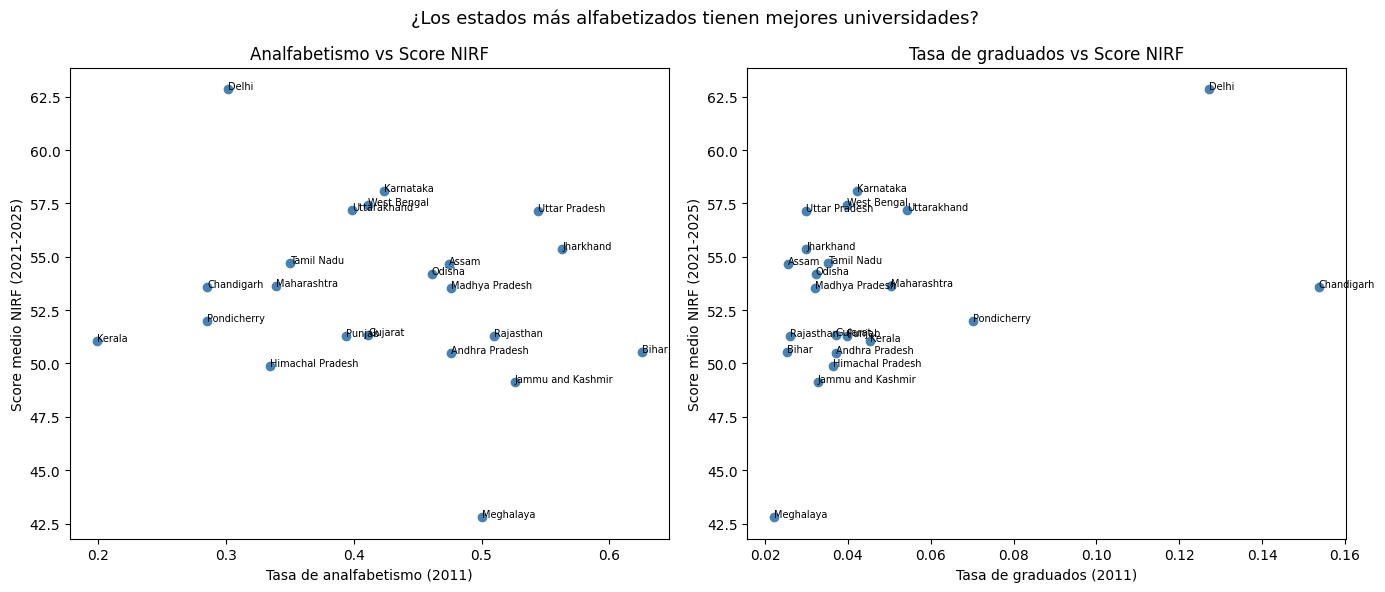

In [47]:
# Punto 2: ¿Los estados más alfabetizados tienen mejores universidades una década despúes?

df_analysis = df_merged.dropna(subset=['Score_mean']).copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: Analfabetismo vs Score
axes[0].scatter(df_analysis['illiterate_persons_rate'], df_analysis['Score_mean'], color='steelblue')
for i, row in df_analysis.iterrows():
    axes[0].annotate(row['State'], (row['illiterate_persons_rate'], row['Score_mean']), fontsize=7)
axes[0].set_xlabel('Tasa de analfabetismo (2011)')
axes[0].set_ylabel('Score medio NIRF (2021-2025)')
axes[0].set_title('Analfabetismo vs Score NIRF')

# Gráfico 2: Graduados vs Score
axes[1].scatter(df_analysis['graduate_persons_rate'], df_analysis['Score_mean'], color='steelblue')
for i, row in df_analysis.iterrows():
    axes[1].annotate(row['State'], (row['graduate_persons_rate'], row['Score_mean']), fontsize=7)
axes[1].set_xlabel('Tasa de graduados (2011)')
axes[1].set_ylabel('Score medio NIRF (2021-2025)')
axes[1].set_title('Tasa de graduados vs Score NIRF')

plt.suptitle('¿Los estados más alfabetizados tienen mejores universidades?', fontsize=13)
plt.tight_layout()
plt.show()

Primer gráfico:

No se observa una tendencia clara. Esperaríamos que a mayor analfabetismo, peor score, pero hay casos que rompen esa lógica:

Delhi tiene una tasa de analfabetismo media (~0.30) pero el score más alto (62.5)

Bihar tiene analfabetismo muy alto (más del 0.6) pero un score medio (50.5)

Kerala tiene el analfabetismo más bajo (0.19) pero un score medio (51)


Esto sugiere que la alfabetización general de la población no determina la calidad de sus universidades.

Segundo gráfico:

Tampoco hay una tendencia fuerte, con dos outliers llamativos:

Delhi: tiene una tasa de graduados alta (0.12) y el mejor score.

Chandigarh: alcanzal la tasa de graduados más alta de todos (0.16) pero score medio (53.5)

Conclusión: La relación entre nivel educativo poblacional (2011) y calidad universitaria (2021-2025) es débil, lo que refuerza lo que comentamos antes: no hay causalidad directa. Factores como inversión pública, políticas educativas o concentración de instituciones de élite pesan más.

Correlaciones entre los indicadores NIRF y el nivel educativo:

,Score_mean,TLR_mean,RPC_mean,GO_mean,OI_mean,PERCEPTION_mean
illiterate_persons_rate,-0.18,-0.18,-0.00,-0.09,-0.37,-0.25
literate_w_o_education_level_persons_rate,-0.12,0.01,-0.07,-0.09,-0.17,-0.14
bellow_primary_persons_rate,-0.14,-0.05,-0.18,0.14,-0.25,-0.05
primary_persons_rate,0.09,0.29,-0.07,-0.13,0.49,0.05
middle_persons_rate,0.10,0.32,-0.07,0.08,0.15,0.05
matric_secondary_persons_rate,0.06,0.05,-0.04,-0.00,0.34,0.10
graduate_persons_rate,0.40,-0.08,0.32,0.17,0.35,0.54


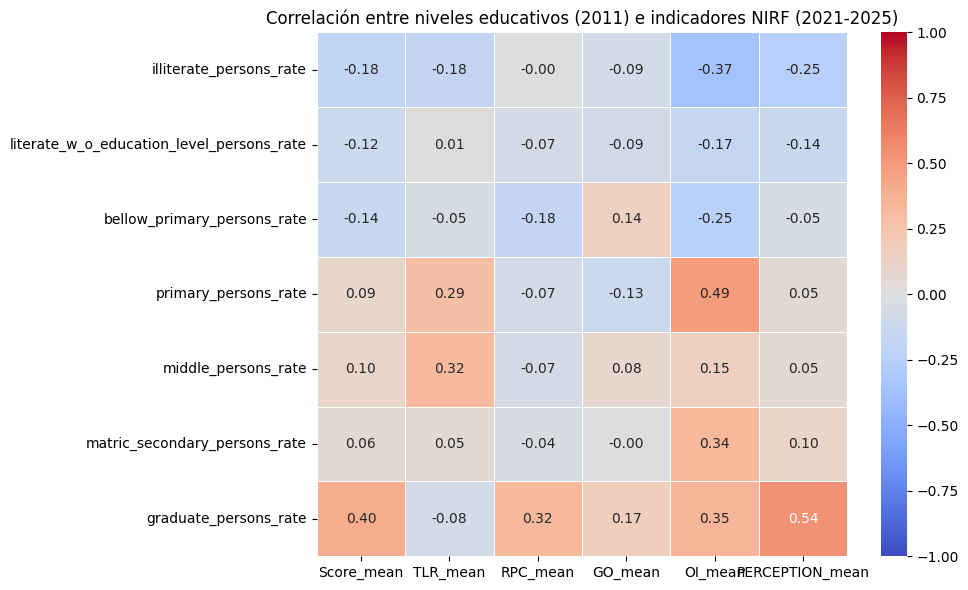

In [48]:
# ¿Qué indicador NIRF correlaciona más con el nivel educativo poblacional?

cols_educ = [
    'illiterate_persons_rate',
    'literate_w_o_education_level_persons_rate',
    'bellow_primary_persons_rate',
    'primary_persons_rate',
    'middle_persons_rate',
    'matric_secondary_persons_rate',
    'graduate_persons_rate'
]

cols_nirf = ['Score_mean', 'TLR_mean', 'RPC_mean', 'GO_mean', 'OI_mean', 'PERCEPTION_mean']

# Matriz de correlación cruzada
corr_cruzada = df_analysis[cols_educ + cols_nirf].corr().loc[cols_educ, cols_nirf]

display(corr_cruzada.round(2))

plt.figure(figsize=(10, 6))
sns.heatmap(corr_cruzada, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, linewidths=0.5)
plt.title("Correlación entre niveles educativos (2011) e indicadores NIRF (2021-2025)")
plt.tight_layout()
plt.show()

Graduate_persons_rate es la variable educativa que más se asocia con los indicadores NIRF:

Con PERCEPTION_mean: 0.54 — los estados con más graduados en 2011 tienden a tener mejor percepción pública de sus universidades en 2021-2025:

Con Score_mean: 0.40 —> asociación moderada positiva.

Con RPC_mean: 0.32 —> cierta asociación con investigación y publicaciones

Illiterate_persons_rate muestra asociaciones negativas:

Con OI_mean: -0.37 —> los estados con más analfabetismo en 2011 tienden a tener peor outreach e inclusividad.

Con PERCEPTION_mean: -0.25

Primary_persons_rate con OI_mean: 0.49 —> asociación positiva posiblemente porque sus universidades pueden hacer un mayor esfuerzo por llegar a poblaciones menos formadas.

Las correlaciones son débiles o moderadas en general. Esto es coherente porque, tal como he comentado en todo el análisis, son dos fuentes temporalmente separadas y miden fenómenos distintos (las tasas educativas miden a la población general del estado, mientras que el NIRF mide instituciones universitarias específicas. Son unidades distintas).

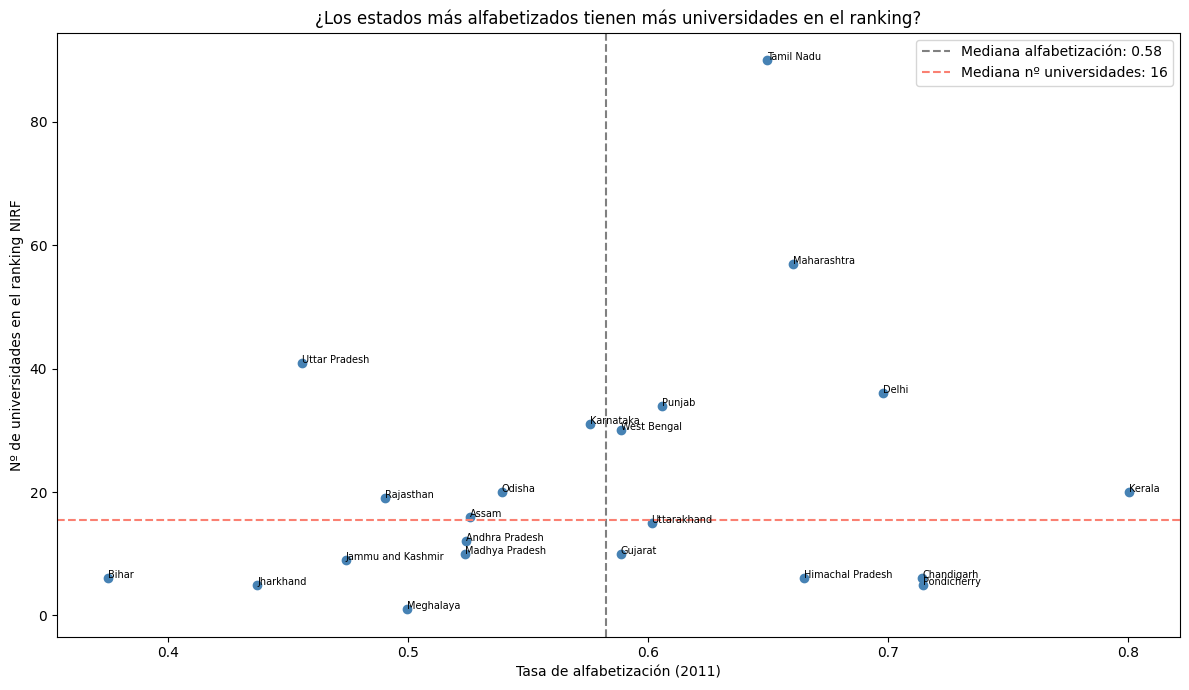

In [49]:
# ¿Hay estados con alta alfabetización pero pocas universidades en el ranking?

fig, ax = plt.subplots(figsize=(12, 7))

ax.scatter(df_analysis['literate_persons_rate'], df_analysis['n_institutos'], color='steelblue')

for i, row in df_analysis.iterrows():
    ax.annotate(row['State'], (row['literate_persons_rate'], row['n_institutos']), fontsize=7)

# Líneas de referencia
ax.axvline(df_analysis['literate_persons_rate'].median(), color='gray', linestyle='--', label=f"Mediana alfabetización: {df_analysis['literate_persons_rate'].median():.2f}")
ax.axhline(df_analysis['n_institutos'].median(), color='salmon', linestyle='--', label=f"Mediana nº universidades: {df_analysis['n_institutos'].median():.0f}")

ax.set_xlabel('Tasa de alfabetización (2011)')
ax.set_ylabel('Nº de universidades en el ranking NIRF')
ax.set_title('¿Los estados más alfabetizados tienen más universidades en el ranking?')
ax.legend()
plt.tight_layout()
plt.show()

Cuadrante superior derecho (alta alfabetización y muchas universidades): esto es lo esperado:

Tamil Nadu es el caso más extremo: con una tasa de alfabetización del 0.60 y 90 universidades aproximadamente. Le sigue Maharashtra y 
después se sitúa Delhi.

Cuadrante superior izquierdo (baja tasa de alfabetización y muchas universidades): esto es más sorprendente:

Uttar Pradesh (con 0.47 de alfabetización pero 41 universidades) —> tiene muchas instituciones pese a ser uno de los estados menos alfabetizados.

Cuadrante inferior derecho (alta tasa de alfabetización y pocas universidades): esto no me cuadra tanto.

Kerala (con el 0.80 de alfabetización, el más alto de todos, pero solo 20 universidades): se trata de un estado muy alfabetizado pero poco representado en el ranking. Le siguen Chandigarh y Pondicherry, también con alta alfabetización pero muy pocas universidades.

Cuadrante inferior izquierdo (baja alfabetización y pocas universidades): esto también es lo esperado:

Estados como Bihar, Jharkhand o Meghalaya: peor desarrollo educativo con pocas universidades.

Conclusión: No hay una asociación clara entre alfabetización poblacional y número de universidades en el ranking. Kerala es el caso más paradójico: el estado más alfabetizado de India tiene una presencia relativamente modesta en el ranking NIRF.

Brecha de género: ¿los estados donde hay más desigualdad entre hombres y mujeres graduadas tienen peores universidades en el ranking?

In [50]:
# Calculamos la brecha de graduados con las tasas que ya tenemos
df_merged['brecha_graduados'] = df_merged['graduate_males_rate'] / df_merged['graduate_females_rate']

# Actualizamos df_analysis
df_analysis = df_merged.dropna(subset=['Score_mean']).copy()

print(df_analysis[['State', 'brecha_graduados']].dropna())

                State  brecha_graduados
1      Andhra Pradesh          2.506095
3               Assam          2.159594
4               Bihar          4.296948
5          Chandigarh          1.035822
9               Delhi          1.170610
11            Gujarat          1.606123
13   Himachal Pradesh          1.830654
14  Jammu and Kashmir          1.982432
15          Jharkhand          2.844069
16          Karnataka          2.084586
17             Kerala          0.996689
19     Madhya Pradesh          2.040062
20        Maharashtra          1.712348
22          Meghalaya          1.315913
25             Odisha          2.642340
26        Pondicherry          1.753142
27             Punjab          1.111866
28          Rajasthan          2.593311
30         Tamil Nadu          1.706679
32      Uttar Pradesh          2.333832
33        Uttarakhand          1.592646
34        West Bengal          2.061231


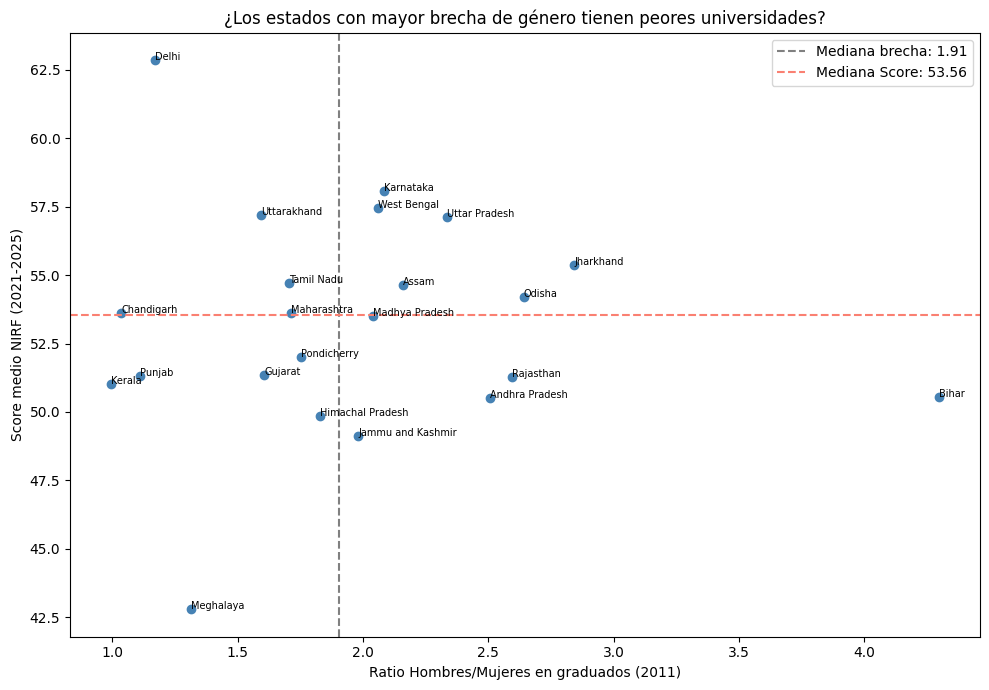

In [51]:
fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(df_analysis['brecha_graduados'], df_analysis['Score_mean'], color='steelblue')

for i, row in df_analysis.iterrows():
    ax.annotate(row['State'], (row['brecha_graduados'], row['Score_mean']), fontsize=7)

ax.axvline(df_analysis['brecha_graduados'].median(), color='gray', linestyle='--',
           label=f"Mediana brecha: {df_analysis['brecha_graduados'].median():.2f}")
ax.axhline(df_analysis['Score_mean'].median(), color='salmon', linestyle='--',
           label=f"Mediana Score: {df_analysis['Score_mean'].median():.2f}")

ax.set_xlabel('Ratio Hombres/Mujeres en graduados (2011)')
ax.set_ylabel('Score medio NIRF (2021-2025)')
ax.set_title('¿Los estados con mayor brecha de género tienen peores universidades?')
ax.legend()
plt.tight_layout()
plt.show()

Este diagrama de puntos muestra que no hay una tendencia clara. Hay casos en ambos sentidos:

Estados con poca desigualdad y buen Score → Delhi.

Estados con mucha desigualdad y buen Score → Uttar Pradesh, Jharkhand.

Estados con poca desigualdad y mal Score → Kerala.

Estados con mucha desigualdad y mal Score → Bihar.

En general, los estados se distribuyen sin seguir una tendencia definida, lo que indica que la desigualdad de género en graduados del 2011 no se asocia de forma clara con la calidad universitaria una década después.

# CONCLUSIÓN EDA

El objetivo del EDA recordamos que era:

Analizar si existe relación entre el nivel educativo de la población india (censo 2011) y la calidad de sus universidades (ranking NIRF 2021-2025), identificando patrones y desigualdades regionales.

Importante: al tratarse de fuentes con un desfase temporal de 10-15 años que miden fenómenos distintos, todas las relaciones encontradas son asociaciones exploratorias, nunca causales. 

1.  Calidad universitaria por estado (df_Rank_state)

El sistema universitario indio tiene una élite muy pequeña (IITs e IISc) que domina el ranking de forma estable año tras año, mientras la mayoría de universidades son peores.

El Score medio entre estados es de 53.3 puntos con poca dispersión (std=4), lo que indica que los estados son bastante homogéneos en calidad general.

Sin embargo, hay una gran desigualdad en representación: el nº de universidades va de 1 a 90, con una mediana de 16. Unos pocos estados concentran la mayoría de universidades.

Tener más universidades no implica mayor calidad: los estados con pocas universidades bien seleccionadas (Jharkhand, Uttarakhand) superan en Score a estados con muchos institutos universitarios (Tamil Nadu, Maharashtra).

El sistema mejora de forma consistente: el Score ha subido de 51.2 en 2021 a 57.8 en 2025, aunque con cierta desaceleración hacia el final del periodo.

El ranking NIRF premia fundamentalmente la investigación y la reputación (RPC–Score=0.85, PERCEPTION–Score=0.86), que además están vinculadas entre sí (RPC–PERCEPTION=0.72). En cambio, la calidad docente (TLR=0.40) y los resultados de graduación (GO=0.30) impactan mucho menos, son homogéneos entre estados y por eso no discriminan, pese a tener valores medios más altos.

2. Análisis a nivel universidad (sin promedios) (df_Rank_final2)

El sistema universitario indio mejora de forma consistente a lo largo del tiempo: el Score medio ha subido de 51.2 en 2021 a 57.8 en 2025, casi 7 puntos en 5 años, sin ningún año de retroceso. La curva parece desacelerarse ligeramente hacia 2024-2025, lo que podría sugerir que el sistema se acerca a un techo, aunque sería necesario un análisis predictivo para confirmarlo.

Bajando al detalle individual, la élite está muy consolidada y es estática: 

- IIT Madras lidera todos los años (86-88) sin rival, 
- IISc es la única con tendencia claramente ascendente recortando distancia con la universidad líder, 
- IIT Bombay e IIT Delhi oscilan de forma estable.

Las posiciones apenas cambian año tras año.

La distribución del Score está sesgada a la derecha: la mayoría de universidades se concentran entre 50 y 56 puntos, y solo unas pocas superan 75 puntos. El hecho de que la media (57.8) supere a la mediana (55.4) confirma que las pocas universidades excelentes tiran de la media hacia arriba, enmascarando una realidad donde hay muchas universidades mediocres y muy pocas excelentes.

3. Nivel educativo de la población (df_Educ_clean)

India muestra una pirámide educativa muy base-pesada: el 40.8% de la población es analfabeta, y los niveles más comunes entre los alfabetizados son primaria e infraprimaria. Solo una minoría alcanza estudios universitarios.

Hay una gran desigualdad regional: Bihar (62.5% analfabetismo) frente a Kerala (20%), el estado históricamente mejor formado.

Alfabetización y tasa de graduados no van siempre de la mano: Kerala es el estado más alfabetizado pero tiene una tasa de graduados media — su fortaleza está en la educación básica, no en la superior. Delhi y Chandigarh lideran en graduados por ser territorios urbanos con alta concentración educativa.

La brecha de género sigue el patrón del analfabetismo: en ningún estado hay más mujeres que hombres graduados. Bihar encabeza negativamente ambos rankings; Kerala, Delhi y Chandigarh son los más igualitarios.

Existe una mejora generacional clara: cuanto más joven es el grupo de edad, menor es el analfabetismo y mayor el nivel educativo alcanzado, lo que es una señal positiva para el futuro del sistema educativo indio.

4. Relación entre educación poblacional y calidad universitaria (df_merged)

La relación entre nivel educativo poblacional (2011) y calidad universitaria (2021-2025) es débil en general, coherente con el desfase temporal y la diferencia de unidades de análisis.

La variable educativa que más se asocia con los indicadores NIRF es graduate_persons_rate, especialmente con PERCEPTION (0.54) y Score (0.40). 

El analfabetismo se asocia negativamente con OI (-0.37) y PERCEPTION (-0.25).

No hay asociación clara entre alfabetización y número de universidades en el ranking: Kerala es el caso más paradójico, el estado más alfabetizado de India tiene una presencia modesta en el NIRF.

La brecha de género en graduados tampoco se asocia claramente con la calidad universitaria: hay estados con mucha desigualdad de género y buen Score (Uttar Pradesh, Jharkhand) y estados con poca desigualdad y Score mediocre (Kerala).

Casos que rompen la lógica esperada: Jharkhand tiene una base educativa muy débil (56% analfabetismo) pero universidades eficientes; Uttar Pradesh tiene analfabetismo alto pero muchas universidades en el ranking; Kerala es el más alfabetizado pero con presencia universitaria modesta.




Conclusión final

El nivel educativo poblacional de un estado no se asocia de forma clara con la calidad de sus universidades. India presenta un sistema universitario con una élite muy consolidada y en mejora continua, que en muchos casos coexiste con una base educativa débil a nivel poblacional, sin que podamos afirmar que una explique a la otra.

 La reputación y la capacidad investigadora son los factores que más diferencian a las mejores universidades, mientras que la alfabetización general o la igualdad de género educativa a nivel poblacional tienen una asociación débil con la calidad universitaria una década después.


In [ ]:
################################## FIN #################################